Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from scipy import stats
import os
from datetime import timedelta
import warnings
from pandas.api.types import is_numeric_dtype
warnings.filterwarnings('ignore')
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Data paths

In [ ]:
scada_2016_path = "/content/drive/MyDrive/School projects/PFE Project/Datasets/2016/Raw data/Wind-Turbine-SCADA-signals-2016.xlsx"
log_failures_2016_path = '/content/drive/MyDrive/School projects/PFE Project/Datasets/2016/Raw data/Historical-Failure-Logbook-2016.xlsx'
metmast_2016_path = '/content/drive/MyDrive/School projects/PFE Project/Datasets/2016/Raw data/Onsite-MetMast-SCADA-data-2016.xlsx'

scada_2017_path = "/content/drive/MyDrive/School projects/PFE Project/Datasets/2017/Wind-Turbine-SCADA-signals-2017_0.xlsx"
metmast_2017_path = '/content/drive/MyDrive/School projects/PFE Project/Datasets/2017/Onsite-MetMast-SCADA-data-2017.xlsx'
log_failures_2017_path = '/content/drive/MyDrive/School projects/PFE Project/Datasets/2017/opendata-wind-failures-2017.xlsx'

In [ ]:
working_direct = "/content/drive/MyDrive/School projects/PFE Project/Datasets"
directory_path = os.path.join(working_direct,"artical_level_data_preparation")

visualizations_path = os.path.join(directory_path, "visualizations")
data_path = os.path.join(directory_path, "data")
models_path = os.path.join(directory_path, "models")
metadata_path = os.path.join(data_path, "metadata")

os.makedirs(metadata_path, exist_ok=True)
os.makedirs(visualizations_path, exist_ok=True)
os.makedirs(data_path, exist_ok=True)
os.makedirs(models_path, exist_ok=True)

# Data Labelling

data preparation steps :
* Data loading and timestamp preparation
* data concatination of the two years version (scada, metmast and failure logbook)
* data merging of scada data with the metmast dataset
* data labeling of the merged scada and metmast dataset using the concatenated faliure logbook dataset.
* sorting the dataset by Turbine_ID and Timestamp
* saving the data to the drive

In [ ]:
def data_load(data_path):
  # load datasets from the drive
  df = pd.read_excel(data_path)
  # convert the timestamp to the appropriate form
  if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    if 'Turbine_ID' in df.columns:
      df = df.sort_values(by=['Turbine_ID','Timestamp'])
  else :
    print('no Timestamp column found!')
  return df

In [ ]:
# merge datasets
def concat_data(df1, df2):
  merged_df = pd.concat([df1, df2], ignore_index = True)
  merged_df['Timestamp'] = pd.to_datetime(merged_df['Timestamp'])
  return merged_df # ignoring the original index for both the datasets and create a new one to avoind duplicate indexes

In [ ]:
def merge_data(df1, df2):
  merged_df = pd.merge(df1, df2, on='Timestamp', how = 'left')
  return merged_df

In [ ]:
def preprocess_data(df1, df2, concat=True):

  if concat:
    df1 = data_load(df1)
    df2 = data_load(df2)
    print(f"loading data is done")

    df = concat_data(df1, df2)
    print("concatination is done")
  else :
    df= merge_data(df1, df2)
    print("merging is done")

  return df

In [ ]:
# concat scada version 2016 and 2017
scada_concat = preprocess_data(scada_2016_path, scada_2017_path)

loading data is done
concatination is done


In [ ]:
scada_concat.head()

,Turbine_ID,Timestamp,Gen_RPM_Max,Gen_RPM_Min,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Phase1_Temp_Avg,Gen_Phase2_Temp_Avg,Gen_Phase3_Temp_Avg,...,Grd_Prod_PsbleInd_Avg,Grd_Prod_PsbleInd_Max,Grd_Prod_PsbleInd_Min,Grd_Prod_PsbleInd_Std,Grd_Prod_PsbleCap_Avg,Grd_Prod_PsbleCap_Max,Grd_Prod_PsbleCap_Min,Grd_Prod_PsbleCap_Std,Gen_Bear2_Temp_Avg,Nac_Direction_Avg
0,T01,2016-01-01 00:00:00+00:00,1277.4,1226.1,1249.0,9.0,41.0,58,59,58,...,-144.4,0.0,-584.5,157.1,144.4,584.5,0.0,157.1,37,218.5
1,T01,2016-01-01 00:10:00+00:00,1268.3,93.3,999.7,435.9,41.0,58,59,59,...,-79.6,0.0,-501.0,123.7,79.6,501.0,0.0,123.7,37,218.5
2,T01,2016-01-01 00:20:00+00:00,1394.4,220.3,774.0,486.1,41.0,57,57,57,...,-314.0,0.0,-1000.0,357.4,314.0,1000.0,0.0,357.4,37,213.3
3,T01,2016-01-01 00:30:00+00:00,1306.6,1212.4,1257.1,17.0,40.0,56,57,57,...,-654.0,0.0,-1000.0,245.8,654.0,1000.0,0.0,245.8,36,222.4
4,T01,2016-01-01 00:40:00+00:00,1320.9,1224.1,1257.7,18.0,40.0,57,58,57,...,-496.1,0.0,-1000.0,302.7,496.1,1000.0,0.0,302.7,36,222.4


In [ ]:
# concate metmast versions 2016 and 2017
metmast_concat = preprocess_data(metmast_2016_path, metmast_2017_path)

loading data is done
concatination is done


In [ ]:
# concate failure versions 2016 and 2017
failure_concat = preprocess_data(log_failures_2016_path, log_failures_2017_path)

loading data is done
concatination is done


In [ ]:
failure_concat.head()

,Turbine_ID,Component,Timestamp,Remarks
0,T01,GEARBOX,2016-07-18 02:10:00+00:00,Gearbox pump damaged
1,T06,HYDRAULIC_GROUP,2016-04-04 18:53:00+00:00,Error in pitch regulation
2,T06,GENERATOR,2016-07-11 19:48:00+00:00,Generator replaced
3,T06,GENERATOR,2016-07-24 17:01:00+00:00,Generator temperature sensor failure
4,T06,GENERATOR,2016-09-04 08:08:00+00:00,High temperature generator error


In [ ]:
# merge concatinated scada with concatinated metmast
scada_concat_merged = preprocess_data(scada_concat, metmast_concat, concat = False)

merging is done


In [ ]:
scada_concat_merged.head()

,Turbine_ID,Timestamp,Gen_RPM_Max,Gen_RPM_Min,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Phase1_Temp_Avg,Gen_Phase2_Temp_Avg,Gen_Phase3_Temp_Avg,...,Anemometer1_CorrOffset,Anemometer2_Freq,Anemometer2_Offset,Anemometer2_CorrGain,Anemometer2_CorrOffset,DistanceAirPress,AirRessureSensorZeroOffset,Anemometer1_Avg_Freq,Anemometer2_Avg_Freq,Pressure_Avg_Freq
0,T01,2016-01-01 00:00:00+00:00,1277.4,1226.1,1249.0,9.0,41.0,58,59,58,...,0.0,0.0499,0.24,1.0,0.0,0.0,600.0,98.0,99.0,418.0
1,T01,2016-01-01 00:10:00+00:00,1268.3,93.3,999.7,435.9,41.0,58,59,59,...,0.0,0.0499,0.24,1.0,0.0,0.0,600.0,99.0,101.0,418.0
2,T01,2016-01-01 00:20:00+00:00,1394.4,220.3,774.0,486.1,41.0,57,57,57,...,0.0,0.0499,0.24,1.0,0.0,0.0,600.0,111.0,113.0,418.0
3,T01,2016-01-01 00:30:00+00:00,1306.6,1212.4,1257.1,17.0,40.0,56,57,57,...,0.0,0.0499,0.24,1.0,0.0,0.0,600.0,122.0,125.0,418.0
4,T01,2016-01-01 00:40:00+00:00,1320.9,1224.1,1257.7,18.0,40.0,57,58,57,...,0.0,0.0499,0.24,1.0,0.0,0.0,600.0,121.0,123.0,417.0


Data labeling function

In [ ]:
def data_labeling(scada, failure, F_window):
  scada['Timestamp']= pd.to_datetime(scada['Timestamp'])
  failure['Timestamp']= pd.to_datetime(failure['Timestamp'])

  # we need to create the label column and initialize it:
  scada['Label'] = 0
  # we need to know the start time of the pre-failure window : failure-time - pre-failure-window
  failure['Pre-failure_Start_Time'] = failure['Timestamp'] - timedelta(days=F_window)
  # we need to extract failure components and indexe it
  components = failure_concat['Component'].unique()
  components_index ={c : i+1 for i ,c in enumerate(components)}

  # we need a mask to capture the periode of pre-failure :
  for i, row in failure.iterrows():
    turbine_id = row['Turbine_ID']
    timestamp = row['Timestamp']
    component = row['Component']
    pre_failure_start_time = row['Pre-failure_Start_Time']

    numerical_label = components_index[component]
    # we need to get data point in this pre_failure window
    scada.loc[
    # We are selecting all rows withen the expresed range as well as the lebel column
      (scada['Turbine_ID'] == turbine_id) &
      (scada['Timestamp'] >= pre_failure_start_time) &
      (scada['Timestamp'] <= timestamp), 'Label'
    ] = numerical_label

  return scada

Labeling the scada (concatinated and merged with metmast) dataset

In [ ]:
scada = data_labeling(scada_concat_merged, failure_concat, 30)

save the data to the drive

In [ ]:
end_point = os.path.join(data_path,"scada_labeled_merged_30days.csv" )
scada.to_csv(end_point,index=False)

In [ ]:
display(scada.groupby('Label').count())

,Turbine_ID,Timestamp,Gen_RPM_Max,Gen_RPM_Min,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Phase1_Temp_Avg,Gen_Phase2_Temp_Avg,Gen_Phase3_Temp_Avg,...,Anemometer1_CorrOffset,Anemometer2_Freq,Anemometer2_Offset,Anemometer2_CorrGain,Anemometer2_CorrOffset,DistanceAirPress,AirRessureSensorZeroOffset,Anemometer1_Avg_Freq,Anemometer2_Avg_Freq,Pressure_Avg_Freq
Label,,,,,,,,,,,,,,,,,,,,,
0,268559,268559,268559,268559,268559,268559,268558,268559,268559,268559,...,208925,208925,208925,208925,208925,208925,208925,208925,208925,208925
1,17245,17245,17245,17245,17245,17245,17245,17245,17245,17245,...,17245,17245,17245,17245,17245,17245,17245,17245,17245,17245
2,59885,59885,59885,59885,59885,59885,59883,59885,59885,59885,...,48644,48644,48644,48644,48644,48644,48644,48644,48644,48644
3,39295,39295,39295,39295,39295,39295,39294,39295,39295,39295,...,39289,39289,39289,39289,39289,39289,39289,39289,39289,39289
4,8810,8810,8810,8810,8810,8810,8810,8810,8810,8810,...,8808,8808,8808,8808,8808,8808,8808,8808,8808,8808
5,23347,23347,23347,23347,23347,23347,23347,23347,23347,23347,...,23347,23347,23347,23347,23347,23347,23347,23347,23347,23347


Data cleaning

In [ ]:
missing_values = scada.isnull().sum()
print(missing_values[missing_values>0])

Gen_Bear_Temp_Avg                 4
Grd_Prod_CosPhi_Avg               4
Min_Windspeed1                70887
Max_Windspeed1                70883
Avg_Windspeed1                70887
Var_Windspeed1                70887
Min_Windspeed2                70887
Max_Windspeed2                70883
Avg_Windspeed2                70887
Var_Windspeed2                70887
Min_Winddirection2            70887
Max_Winddirection2            70883
Avg_Winddirection2            70887
Var_Winddirection2            70907
Min_AmbientTemp               70887
Max_AmbientTemp               70883
Avg_AmbientTemp               70887
Min_Pressure                  70887
Max_Pressure                  70883
Avg_Pressure                  70887
Min_Humidity                  70887
Max_Humidity                  70883
Avg_Humidity                  70887
Min_Precipitation             70883
Max_Precipitation             70883
Avg_Precipitation             70883
Min_Raindetection             70883
Max_Raindetection           

In [ ]:
scada_cleaned = scada.copy()

In [ ]:
scada.head()

,Turbine_ID,Timestamp,Gen_RPM_Max,Gen_RPM_Min,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Phase1_Temp_Avg,Gen_Phase2_Temp_Avg,Gen_Phase3_Temp_Avg,...,Anemometer2_Freq,Anemometer2_Offset,Anemometer2_CorrGain,Anemometer2_CorrOffset,DistanceAirPress,AirRessureSensorZeroOffset,Anemometer1_Avg_Freq,Anemometer2_Avg_Freq,Pressure_Avg_Freq,Label
0,T01,2016-01-01 00:00:00+00:00,1277.4,1226.1,1249.0,9.0,41.0,58,59,58,...,0.0499,0.24,1.0,0.0,0.0,600.0,98.0,99.0,418.0,0
1,T01,2016-01-01 00:10:00+00:00,1268.3,93.3,999.7,435.9,41.0,58,59,59,...,0.0499,0.24,1.0,0.0,0.0,600.0,99.0,101.0,418.0,0
2,T01,2016-01-01 00:20:00+00:00,1394.4,220.3,774.0,486.1,41.0,57,57,57,...,0.0499,0.24,1.0,0.0,0.0,600.0,111.0,113.0,418.0,0
3,T01,2016-01-01 00:30:00+00:00,1306.6,1212.4,1257.1,17.0,40.0,56,57,57,...,0.0499,0.24,1.0,0.0,0.0,600.0,122.0,125.0,418.0,0
4,T01,2016-01-01 00:40:00+00:00,1320.9,1224.1,1257.7,18.0,40.0,57,58,57,...,0.0499,0.24,1.0,0.0,0.0,600.0,121.0,123.0,417.0,0


In [ ]:
scada_cleaned.head()

,Timestamp,Gen_RPM_Max,Gen_RPM_Min,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Phase1_Temp_Avg,Gen_Phase2_Temp_Avg,Gen_Phase3_Temp_Avg,Hyd_Oil_Temp_Avg,...,Anemometer2_Freq,Anemometer2_Offset,Anemometer2_CorrGain,Anemometer2_CorrOffset,DistanceAirPress,AirRessureSensorZeroOffset,Anemometer1_Avg_Freq,Anemometer2_Avg_Freq,Pressure_Avg_Freq,Label
0,2016-01-01 00:00:00+00:00,1277.4,1226.1,1249.0,9.0,41.0,58,59,58,30,...,0.0499,0.24,1.0,0.0,0.0,600.0,98.0,99.0,418.0,0
1,2016-01-01 00:10:00+00:00,1268.3,93.3,999.7,435.9,41.0,58,59,59,30,...,0.0499,0.24,1.0,0.0,0.0,600.0,99.0,101.0,418.0,0
2,2016-01-01 00:20:00+00:00,1394.4,220.3,774.0,486.1,41.0,57,57,57,30,...,0.0499,0.24,1.0,0.0,0.0,600.0,111.0,113.0,418.0,0
3,2016-01-01 00:30:00+00:00,1306.6,1212.4,1257.1,17.0,40.0,56,57,57,30,...,0.0499,0.24,1.0,0.0,0.0,600.0,122.0,125.0,418.0,0
4,2016-01-01 00:40:00+00:00,1320.9,1224.1,1257.7,18.0,40.0,57,58,57,30,...,0.0499,0.24,1.0,0.0,0.0,600.0,121.0,123.0,417.0,0


In [ ]:
def handle_missing_values(df, drop_threshold=0.5):
    """
    Handle missing values using forward/backward imputation and row dropping

    Parameters:
    - df: SCADA dataframe (sorted by Turbine_ID, Timestamp)
    - drop_threshold: if row has > this fraction of missing values, drop it

    Returns:
    - cleaned dataframe
    """
    print(f"Initial shape: {df.shape}")
    print(f"Initial missing values: {df.isnull().sum().sum()}")

    # Step 1: Drop rows with too many missing values
    missing_ratio = df.isnull().sum(axis=1) / df.shape[1]
    rows_to_drop = missing_ratio > drop_threshold
    df_clean = df[~rows_to_drop].copy()

    print(f"Dropped {rows_to_drop.sum()} rows with >{drop_threshold*100}% missing")

    # Step 2: Forward fill then backward fill within each turbine
    df_clean = df_clean.groupby('Turbine_ID', group_keys=False).apply(
        lambda group: group.fillna(method='ffill').fillna(method='bfill')
    )

    # Step 3: Drop any remaining rows with missing values
    df_clean = df_clean.dropna()

    print(f"Final shape: {df_clean.shape}")
    print(f"Final missing values: {df_clean.isnull().sum().sum()}")

    return df_clean

In [ ]:
scada_cleaned = handle_missing_values(scada, drop_threshold=0.35)

Initial shape: (417141, 124)
Initial missing values: 2835408
Dropped 0 rows with >35.0% missing
Final shape: (417141, 124)
Final missing values: 0


## Data Downsampling

In [ ]:
# Define the extended window (6 months)
extended_window = timedelta(days=8*30) # Approximate 8 months

# Get all normal operation data points
normal_operation_df = scada_merged[scada_merged['failure_label'] == 0].copy()

# Initialize a boolean mask for normal operation data points within any extended failure window
within_extended_window_for_normal_op_mask = pd.Series(False, index=normal_operation_df.index)

# Iterate through each failure event
for index, row in failure_logs_merged.iterrows():
    turbine_id = row['Turbine_ID']
    failure_timestamp = row['Timestamp']
    extended_window_start = failure_timestamp - extended_window

    # Create a mask for normal operation data points within the current extended failure window for the specific turbine
    current_window_mask = (normal_operation_df['Turbine_ID'] == turbine_id) & \
                          (normal_operation_df['Timestamp'] >= extended_window_start) & \
                          (normal_operation_df['Timestamp'] <= failure_timestamp)

    # Update the overall mask for normal operation data points
    within_extended_window_for_normal_op_mask = within_extended_window_for_normal_op_mask | current_window_mask

# Filter for normal operation data points that are NOT within any extended failure window
out_of_extended_window_normal_operation = normal_operation_df[~within_extended_window_for_normal_op_mask]

# Count the number of such data points
count_out_of_window = len(out_of_extended_window_normal_operation)

print(f"Number of data points labeled as normal operation (0) outside any 6-month pre-failure window: {count_out_of_window}")

Number of data points labeled as normal operation (0) outside any 6-month pre-failure window: 95025


In [ ]:
# Get the indices of the data points to remove
indices_to_remove = out_of_extended_window_normal_operation.index

# Remove the data points from the scada_merged DataFrame
scada_merged_filtered = scada_merged.drop(indices_to_remove)

# Display the shape of the filtered DataFrame to confirm the removal
print(f"Shape of the original DataFrame: {scada_merged.shape}")
print(f"Shape of the filtered DataFrame: {scada_merged_filtered.shape}")

# Display the value counts of the 'failure_label' column in the filtered DataFrame
display(scada_merged_filtered['failure_label'].value_counts())

Shape of the original DataFrame: (417141, 84)
Shape of the filtered DataFrame: (322116, 84)


,count
failure_label,
0,240877
3,30189
2,25006
5,12886
1,8641
4,4517


In [ ]:
# scada_merged_filtered.to_csv(os.path.join(data_path, "scada_downsampling_8months_60d.csv"))

In [ ]:
# Display the value counts of the 'failure_label' column in scada_merged
class_dist = scada_merged_filtered['failure_label'].value_counts()

class_dist_path = os.path.join(metadata_path, "scada_class_distribution_8Months_downsamplin_60d.csv")
class_dist.to_csv(class_dist_path,header=['count'])
print(f"successfully loaded to :{class_dist_path}")

successfully loaded to :/content/drive/MyDrive/School projects/PFE Project/Datasets/artical_level_data_preparation/data/metadata/scada_class_distribution_8Months_downsamplin_60d.csv


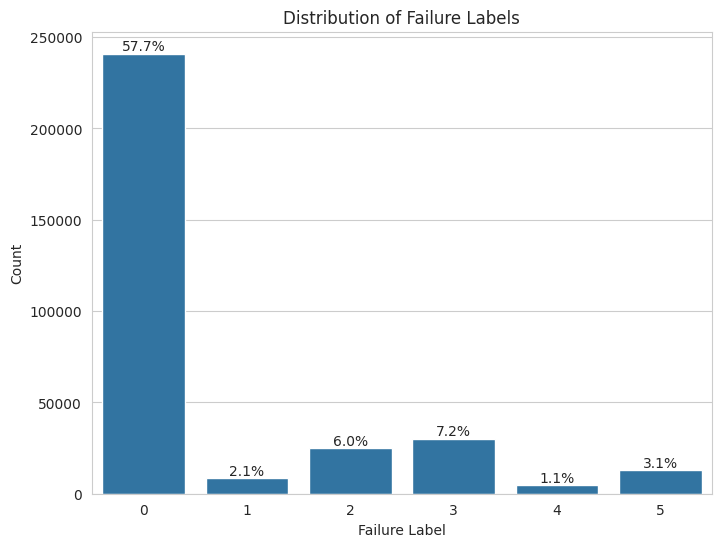

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a polished seaborn style
sns.set_style("whitegrid")

# Plot the class distribution
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='failure_label', data=scada_merged_filtered)
plt.title('Distribution of Failure Labels')
plt.xlabel('Failure Label')
plt.ylabel('Count')

# Add percentages on top of the bars
total = len(scada_merged)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2.
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

# Save the figure before showing it
plt.savefig(os.path.join(visualizations_path, "scada_data_distribution_8Months_downsamplin_30d.png"))

plt.show()

In [ ]:
scada_2017 = pd.read_excel(scada_2017_path)
scada_2016 = pd.read_excel(scada_2016_path)

scada_merged = pd.concat([scada_2016, scada_2017], ignore_index=True)

In [ ]:

metmast_2017 = pd.read_excel(metmast_2017_path)
metmast_2016 = pd.read_excel(metmast_2016_path)
metmast = pd.concat([metmast_2016, metmast_2017], ignore_index= True)

metmast['Timestamp'] = pd.to_datetime(metmast['Timestamp'])

In [ ]:
scada_merged['Timestamp'] = pd.to_datetime(scada_merged['Timestamp'])
scada_metmast = pd.merge(scada_merged, metmast, on='Timestamp', how='left')

In [ ]:
scada_metmast.head()

,Turbine_ID,Timestamp,Gen_RPM_Max,Gen_RPM_Min,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Phase1_Temp_Avg,Gen_Phase2_Temp_Avg,Gen_Phase3_Temp_Avg,...,Anemometer2_Offset,Anemometer2_CorrGain,Anemometer2_CorrOffset,DistanceAirPress,AirRessureSensorZeroOffset,Anemometer1_Avg_Freq,Anemometer2_Avg_Freq,Pressure_Avg_Freq,Label,failure_label
0,T06,2016-01-08 23:10:00+00:00,1634.3,1226.9,1416.4,96.4,49.0,62,63,64,...,0.24,1.0,0.0,0.0,600.0,164.0,166.0,406.0,-1,NaN
1,T06,2016-04-19 12:20:00+00:00,1796.1,1597.0,1680.0,29.8,66.0,97,107,111,...,0.24,1.0,0.0,0.0,600.0,258.0,259.0,405.0,-1,NaN
2,T01,2016-01-08 23:10:00+00:00,1657.5,1299.2,1495.0,83.8,47.0,62,62,61,...,0.24,1.0,0.0,0.0,600.0,164.0,166.0,406.0,-1,NaN
3,T11,2016-04-19 12:30:00+00:00,1771.2,1590.0,1677.5,29.4,66.0,111,110,110,...,0.24,1.0,0.0,0.0,600.0,187.0,188.0,405.0,-1,NaN
4,T07,2016-01-08 23:50:00+00:00,1667.5,1277.4,1481.3,119.1,46.0,73,72,71,...,0.24,1.0,0.0,0.0,600.0,157.0,158.0,405.0,-1,NaN


# Feature selection

Data loading

In [ ]:
scada_60 = pd.read_csv(os.path.join(data_path,"scada_labeled_merged_60days.csv"))
scada_30 = pd.read_csv(os.path.join(data_path,"scada_labeled_merged_30days.csv"))

In [ ]:
scada_60.head()

,Turbine_ID,Timestamp,Gen_RPM_Max,Gen_RPM_Min,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Phase1_Temp_Avg,Gen_Phase2_Temp_Avg,Gen_Phase3_Temp_Avg,...,Anemometer2_Freq,Anemometer2_Offset,Anemometer2_CorrGain,Anemometer2_CorrOffset,DistanceAirPress,AirRessureSensorZeroOffset,Anemometer1_Avg_Freq,Anemometer2_Avg_Freq,Pressure_Avg_Freq,Label
0,T01,2016-01-01 00:00:00+00:00,1277.4,1226.1,1249.0,9.0,41.0,58,59,58,...,0.0499,0.24,1.0,0.0,0.0,600.0,98.0,99.0,418.0,0
1,T01,2016-01-01 00:10:00+00:00,1268.3,93.3,999.7,435.9,41.0,58,59,59,...,0.0499,0.24,1.0,0.0,0.0,600.0,99.0,101.0,418.0,0
2,T01,2016-01-01 00:20:00+00:00,1394.4,220.3,774.0,486.1,41.0,57,57,57,...,0.0499,0.24,1.0,0.0,0.0,600.0,111.0,113.0,418.0,0
3,T01,2016-01-01 00:30:00+00:00,1306.6,1212.4,1257.1,17.0,40.0,56,57,57,...,0.0499,0.24,1.0,0.0,0.0,600.0,122.0,125.0,418.0,0
4,T01,2016-01-01 00:40:00+00:00,1320.9,1224.1,1257.7,18.0,40.0,57,58,57,...,0.0499,0.24,1.0,0.0,0.0,600.0,121.0,123.0,417.0,0


In [ ]:
X = scada_60.drop(columns=['Label'])
y = scada_60['Label']

In [ ]:
y.describe()

,Label
count,417141.000000
mean,0.975390
std,1.499719
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,5.000000


In [ ]:
import pandas as pd
import numpy as np
from datetime import timedelta

# ============================================================================
# DATA PREPROCESSING WITH CUSTOM SPLIT & 2-MONTH DROP
# ============================================================================

def ts_split(data, test_size=92, val_size=61):
    """
    Time-series split function
    """
    data['Timestamp'] = pd.to_datetime(data['Timestamp'])
    data = data.sort_values(['Turbine_ID', 'Timestamp'])

    # Define start time of every set
    max_time = data['Timestamp'].max()
    test_start_time = max_time - timedelta(days=test_size)
    validation_start_time = test_start_time - timedelta(days=val_size)

    train_set = data[data['Timestamp'] < validation_start_time]
    val_set = data[(data['Timestamp'] >= validation_start_time) & (data['Timestamp'] < test_start_time)]
    test_set = data[data['Timestamp'] >= test_start_time]

    return train_set, val_set, test_set


def prepare_data_for_feature_selection(scada_data, turbine_col='Turbine_ID',
                                       timestamp_col='Timestamp',
                                       target_col='Label',
                                       drop_last_months=2):
    """
    Prepare labeled SCADA data for feature selection

    Parameters:
    - scada_data: DataFrame with ~120 features + labels (0-5 for 6 classes)
    - turbine_col: turbine identifier column
    - timestamp_col: timestamp column
    - target_col: label column (6 classes)
    - drop_last_months: number of months to drop from end (default=2)

    Returns:
    - X_train, X_val, X_test, y_train, y_val, y_test
    """

    print("="*70)
    print("DATA PREPARATION FOR FEATURE SELECTION")
    print("="*70)

    # Step 1: Drop last 2 months (only normal class samples)
    print("\nStep 1: Removing last 2 months of data...")

    scada_data = scada_data.copy()
    scada_data[timestamp_col] = pd.to_datetime(scada_data[timestamp_col])

    # Drop last 2 months
    scada_filtered = scada_data[scada_data[timestamp_col] < '2017-11-01'].copy()

    print(f"  Original samples: {len(scada_data)}")
    print(f"  After dropping last 2 months: {len(scada_filtered)}")
    print(f"  Removed: {len(scada_data) - len(scada_filtered)} samples")

    # Step 2: Separate features and target
    print("\nStep 2: Separating features and target...")

    # Columns to exclude from features
    exclude_cols = [turbine_col, timestamp_col, target_col]

    # Get feature columns
    feature_cols = [col for col in scada_filtered.columns if col not in exclude_cols]

    print(f"  Features: {len(feature_cols)}")
    print(f"  Samples: {len(scada_filtered)}")

    # Check target distribution before split
    print(f"\n  Overall class distribution:")
    print(scada_filtered[target_col].value_counts().sort_index())

    # Step 3: Time-series split using ts_split function
    print("\nStep 3: Time-series split (test=92 days, val=61 days)...")

    train_data, val_data, test_data = ts_split(scada_filtered, test_size=92, val_size=61)

    print(f"  Train: {len(train_data)} samples")
    print(f"  Val:   {len(val_data)} samples")
    print(f"  Test:  {len(test_data)} samples")

    # Extract X and y for each split
    X_train = train_data[feature_cols].reset_index(drop=True)
    y_train = train_data[target_col].reset_index(drop=True)

    X_val = val_data[feature_cols].reset_index(drop=True)
    y_val = val_data[target_col].reset_index(drop=True)

    X_test = test_data[feature_cols].reset_index(drop=True)
    y_test = test_data[target_col].reset_index(drop=True)

    # Step 4: Check class distribution in each split
    print("\nStep 4: Checking class distribution per split...")

    print("\n  Training set:")
    print(y_train.value_counts().sort_index())

    print("\n  Validation set:")
    print(y_val.value_counts().sort_index())

    print("\n  Test set:")
    print(y_test.value_counts().sort_index())

    # Step 5: Handle missing values (if any remain)
    print("\nStep 5: Checking for missing values...")

    train_missing = X_train.isnull().sum().sum()
    val_missing = X_val.isnull().sum().sum()
    test_missing = X_test.isnull().sum().sum()

    if train_missing > 0 or val_missing > 0 or test_missing > 0:
        print(f"  WARNING: Found missing values!")
        print(f"    Train: {train_missing}")
        print(f"    Val: {val_missing}")
        print(f"    Test: {test_missing}")
        print(f"  Applying forward/backward fill...")

        X_train = X_train.fillna(method='ffill').fillna(method='bfill')
        X_val = X_val.fillna(method='ffill').fillna(method='bfill')
        X_test = X_test.fillna(method='ffill').fillna(method='bfill')

        # Drop any remaining NaN rows
        if X_train.isnull().any().any():
            initial_len = len(X_train)
            mask = ~X_train.isnull().any(axis=1)
            X_train = X_train[mask]
            y_train = y_train[mask]
            print(f"    Dropped {initial_len - len(X_train)} rows from train")

        if X_val.isnull().any().any():
            initial_len = len(X_val)
            mask = ~X_val.isnull().any(axis=1)
            X_val = X_val[mask]
            y_val = y_val[mask]
            print(f"    Dropped {initial_len - len(X_val)} rows from val")

        if X_test.isnull().any().any():
            initial_len = len(X_test)
            mask = ~X_test.isnull().any(axis=1)
            X_test = X_test[mask]
            y_test = y_test[mask]
            print(f"    Dropped {initial_len - len(X_test)} rows from test")

        print(f"  ✓ Missing values handled")
    else:
        print(f"  ✓ No missing values found")

    # Reset indices
    X_train = X_train.reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)

    X_val = X_val.reset_index(drop=True)
    y_val = y_val.reset_index(drop=True)

    X_test = X_test.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)

    print("\n" + "="*70)
    print("DATA PREPARATION COMPLETE")
    print("="*70)
    print(f"Final shapes:")
    print(f"  Train: {X_train.shape}")
    print(f"  Val:   {X_val.shape}")
    print(f"  Test:  {X_test.shape}")
    print(f"Ready for feature selection with {X_train.shape[1]} features")

    return X_train, X_val, X_test, y_train, y_val, y_test


# ============================================================================
# COMPLETE WORKFLOW
# ============================================================================

def complete_workflow(scada_data, component='GENERATOR'):
    """
    Complete preprocessing + feature selection workflow

    Parameters:
    - scada_data: Your labeled SCADA data with ~120 features
    - component: Component name (for reference)
    """

    # Step 1: Prepare data (includes 2-month drop + ts_split)
    X_train, X_val, X_test, y_train, y_val, y_test = prepare_data_for_feature_selection(
        scada_data,
        turbine_col='Turbine_ID',
        timestamp_col='Timestamp',
        target_col='Label',  # Your 6-class label (0-5)
        drop_last_months=2
    )

    # Step 2: Initialize feature selector
    selector = StatisticalFeatureSelector(
        task='classification',
        n_classes=6,
        average='weighted'
    )

    # Step 3: Run feature selection
    print("\n" + "="*70)
    print(f"Starting feature selection for {component}...")
    print("="*70)

    best_features = selector.select_best_features(X_train, y_train, X_val, y_val)

    # Step 4: Transform data
    X_train_selected = selector.transform(X_train)
    X_val_selected = selector.transform(X_val)
    X_test_selected = selector.transform(X_test)

    print(f"\n✓ Feature selection complete!")
    print(f"  Original features: {X_train.shape[1]}")
    if isinstance(best_features, list):
        print(f"  Selected features: {len(best_features)}")
        print(f"  Selected feature names: {best_features[:10]}..." if len(best_features) > 10 else f"  Selected feature names: {best_features}")
    else:
        print(f"  Transformed to: {X_train_selected.shape[1]} components")

    return X_train_selected, X_val_selected, X_test_selected, y_train, y_val, y_test, selector


# ============================================================================
# USAGE
# ============================================================================

"""
# Load your labeled SCADA data
scada_data = pd.read_csv('labeled_scada_data.csv')

# Run complete workflow
X_train, X_val, X_test, y_train, y_val, y_test, selector = complete_workflow(
    scada_data,
    component='GENERATOR'
)

# Now ready for model training!
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Evaluate on test set
y_pred = model.predict(X_test)
print("\nTest Set Results:")
print(classification_report(y_test, y_pred))
print(f"Weighted F1 Score: {f1_score(y_test, y_pred, average='weighted'):.4f}")
"""

'\n# Load your labeled SCADA data\nscada_data = pd.read_csv(\'labeled_scada_data.csv\')\n\n# Run complete workflow\nX_train, X_val, X_test, y_train, y_val, y_test, selector = complete_workflow(\n    scada_data, \n    component=\'GENERATOR\'\n)\n\n# Now ready for model training!\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.metrics import classification_report, f1_score\n\nmodel = RandomForestClassifier(random_state=42)\nmodel.fit(X_train, y_train)\n\n# Evaluate on test set\ny_pred = model.predict(X_test)\nprint("\nTest Set Results:")\nprint(classification_report(y_test, y_pred))\nprint(f"Weighted F1 Score: {f1_score(y_test, y_pred, average=\'weighted\'):.4f}")\n'

## Knowledge-Based Feature Selection

In [ ]:
features_to_keep = [
    'Timestamp',  # Keep timestamp for time series analysis
    'Turbine_ID', # Keep turbine ID for identification

    # SCADA features
    'Gen_RPM_Avg',
    'Gen_RPM_Std',
    'Gen_Bear_Temp_Avg',
    'Gen_Bear2_Temp_Avg',
    'Gen_SlipRing_Temp_Avg',
    'Gear_Oil_Temp_Avg',
    'Gear_Bear_Temp_Avg',
    'Hyd_Oil_Temp_Avg',
    'Rtr_RPM_Avg',
    'Rtr_RPM_Std',
    'Blds_PitchAngle_Avg',
    'Prod_LatestAvg_TotActPwr',
    'Grd_Prod_Pwr_Std',
    'Grd_Prod_VoltPhse1_Avg',
    'Grd_Prod_VoltPhse2_Avg',
    'Grd_Prod_VoltPhse3_Avg',
    'Amb_WindSpeed_Avg',
    'Amb_WindSpeed_Std',
    'Nac_Direction_Avg',

    # MetMast features
    'Avg_Windspeed1',
    'Var_Windspeed1',
    'Avg_Windspeed2',
    'Avg_Winddirection2',
    'Avg_AmbientTemp',
    'Avg_Humidity',
    'Avg_Pressure',
    'Label'
]

In [ ]:
scada_60_selected =scada_test_60[features_to_keep]
scada_60_selected.head()

,Timestamp,Turbine_ID,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Bear2_Temp_Avg,Gen_SlipRing_Temp_Avg,Gear_Oil_Temp_Avg,Gear_Bear_Temp_Avg,Hyd_Oil_Temp_Avg,...,Amb_WindSpeed_Std,Nac_Direction_Avg,Avg_Windspeed1,Var_Windspeed1,Avg_Windspeed2,Avg_Winddirection2,Avg_AmbientTemp,Avg_Humidity,Avg_Pressure,Label
0,2016-01-01 00:00:00+00:00,T01,1249.0,9.0,41.0,37,25,44,48,30,...,0.9,218.5,5.1,0.21,5.1,236.0,17.0,90.0,1018.0,0
1,2016-01-01 00:10:00+00:00,T01,999.7,435.9,41.0,37,25,44,48,30,...,0.9,218.5,5.1,0.09,5.2,236.0,17.0,87.0,1018.0,0
2,2016-01-01 00:20:00+00:00,T01,774.0,486.1,41.0,37,25,43,46,30,...,1.0,213.3,5.7,0.26,5.8,236.0,17.0,90.0,1018.0,0
3,2016-01-01 00:30:00+00:00,T01,1257.1,17.0,40.0,36,25,44,48,30,...,1.1,222.4,6.3,0.11,6.4,236.0,17.0,90.0,1018.0,0
4,2016-01-01 00:40:00+00:00,T01,1257.7,18.0,40.0,36,25,44,48,30,...,1.2,222.4,6.2,0.27,6.3,236.0,17.0,90.0,1018.0,0


In [ ]:
scada_30_selected =scada_test_30[features_to_keep]
scada_30_selected.head()

,Timestamp,Turbine_ID,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Bear2_Temp_Avg,Gen_SlipRing_Temp_Avg,Gear_Oil_Temp_Avg,Gear_Bear_Temp_Avg,Hyd_Oil_Temp_Avg,...,Amb_WindSpeed_Std,Nac_Direction_Avg,Avg_Windspeed1,Var_Windspeed1,Avg_Windspeed2,Avg_Winddirection2,Avg_AmbientTemp,Avg_Humidity,Avg_Pressure,Label
0,2016-01-01 00:00:00+00:00,T01,1249.0,9.0,41.0,37,25,44,48,30,...,0.9,218.5,5.1,0.21,5.1,236.0,17.0,90.0,1018.0,0
1,2016-01-01 00:10:00+00:00,T01,999.7,435.9,41.0,37,25,44,48,30,...,0.9,218.5,5.1,0.09,5.2,236.0,17.0,87.0,1018.0,0
2,2016-01-01 00:20:00+00:00,T01,774.0,486.1,41.0,37,25,43,46,30,...,1.0,213.3,5.7,0.26,5.8,236.0,17.0,90.0,1018.0,0
3,2016-01-01 00:30:00+00:00,T01,1257.1,17.0,40.0,36,25,44,48,30,...,1.1,222.4,6.3,0.11,6.4,236.0,17.0,90.0,1018.0,0
4,2016-01-01 00:40:00+00:00,T01,1257.7,18.0,40.0,36,25,44,48,30,...,1.2,222.4,6.2,0.27,6.3,236.0,17.0,90.0,1018.0,0


upload the selected dataset into the drive

In [ ]:
selected_path = data_path+'/selected_scada'
os.mkdir(selected_path)

FileExistsError: [Errno 17] File exists: '/content/drive/MyDrive/School projects/PFE Project/Datasets/artical_level_data_preparation/data/selected_scada'

In [ ]:
display(selected_path)

'/content/drive/MyDrive/School projects/PFE Project/Datasets/artical_level_data_preparation/data/selected_scada'

In [ ]:
scada_30_selected.to_csv(selected_path+'/knowledge_selected_scada_30.csv', index =False)
scada_60_selected.to_csv(selected_path+'/knowledge_selected_scada_60.csv', index =False)

## Statistical based selection

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.decomposition import PCA, FastICA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

class StatisticalFeatureSelector:
    """Optimized statistical feature selection for SCADA time-series data"""

    def __init__(self, task='classification', n_classes=6, average='weighted'):
        self.task = task
        self.n_classes = n_classes
        self.average = average  # 'weighted', 'macro', or 'micro'
        self.best_features = None
        self.best_score = 0
        self.best_method = None

    def prefilter_features(self, X, y):
        """Step 1: Remove non-informative features"""
        print(f"Initial features: {X.shape[1]}")

        # Remove zero variance
        variances = X.var()
        X = X.loc[:, variances > 0]
        print(f"After zero variance removal: {X.shape[1]}")

        # Remove low variance (σ² < 0.0001)
        variances = X.var()
        X = X.loc[:, variances >= 0.0001]
        print(f"After low variance removal: {X.shape[1]}")

        # Remove technical parameters
        tech_keywords = ['offset', 'sampling', 'rate', 'scale']
        cols_to_keep = [col for col in X.columns
                        if not any(kw in col.lower() for kw in tech_keywords)]
        X = X[cols_to_keep]
        print(f"After technical parameter removal: {X.shape[1]}")

        return X

    def _continuous_to_class(self, y_continuous):
        """Convert continuous RUL to multi-class labels (if needed)"""
        # Adjust bins according to your class definition
        bins = [-np.inf, 10, 20, 30, 40, 50, np.inf]
        labels = [0, 1, 2, 3, 4, 5]
        return pd.cut(y_continuous, bins=bins, labels=labels).astype(int)

    def _evaluate_features(self, X_train, y_train, X_val, y_val, features):
        """Evaluate selected features using base model"""
        if self.task == 'classification':
            model = DecisionTreeClassifier(random_state=42, max_depth=10)
        else:
            model = DecisionTreeRegressor(random_state=42, max_depth=10)

        X_train_sub = X_train[features] if isinstance(features, list) else X_train.iloc[:, features]
        X_val_sub = X_val[features] if isinstance(features, list) else X_val.iloc[:, features]

        model.fit(X_train_sub, y_train)
        y_pred = model.predict(X_val_sub)

        # Multi-class F1 score
        if self.task == 'classification':
            return f1_score(y_val, y_pred, average=self.average, zero_division=0)
        else:
            # For regression, convert continuous predictions to classes
            y_val_class = self._continuous_to_class(y_val)
            y_pred_class = self._continuous_to_class(y_pred)
            return f1_score(y_val_class, y_pred_class, average=self.average, zero_division=0)

    def feature_importance_selection(self, X_train, y_train, X_val, y_val):
        """Method 1: Feature importance selector"""
        print("\n[1/5] Testing Feature Importance Selector...")

        if self.task == 'classification':
            model = DecisionTreeClassifier(random_state=42, max_depth=10)
        else:
            model = DecisionTreeRegressor(random_state=42, max_depth=10)

        model.fit(X_train, y_train)
        importances = pd.Series(model.feature_importances_, index=X_train.columns)

        best_n, best_score = 0, 0
        for n_features in range(10, min(91, len(X_train.columns)), 10):
            top_features = importances.nlargest(n_features).index.tolist()
            score = self._evaluate_features(X_train, y_train, X_val, y_val, top_features)

            if score > best_score:
                best_score = score
                best_n = n_features

        print(f"  Best: {best_n} features, F1={best_score:.4f}")
        return importances.nlargest(best_n).index.tolist(), best_score

    def correlation_filter(self, X_train, y_train, X_val, y_val):
        """Method 2: High correlation filter"""
        print("\n[2/5] Testing High Correlation Filter...")

        corr_matrix = X_train.corr().abs()

        best_threshold, best_score, best_features = 0, 0, None
        for threshold in np.arange(0.5, 1.0, 0.1):
            selected = []
            dropped = set()

            for i in range(len(corr_matrix.columns)):
                if corr_matrix.columns[i] in dropped:
                    continue

                selected.append(corr_matrix.columns[i])

                for j in range(i+1, len(corr_matrix.columns)):
                    if corr_matrix.iloc[i, j] > threshold:
                        dropped.add(corr_matrix.columns[j])

            if len(selected) < 5:
                continue

            score = self._evaluate_features(X_train, y_train, X_val, y_val, selected)

            if score > best_score:
                best_score = score
                best_threshold = threshold
                best_features = selected

        print(f"  Best: threshold={best_threshold:.1f}, {len(best_features)} features, F1={best_score:.4f}")
        return best_features, best_score

    def mutual_information_selection(self, X_train, y_train, X_val, y_val):
        """Method 3: Mutual information selector"""
        print("\n[3/5] Testing Mutual Information Selector...")

        if self.task == 'classification':
            mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
        else:
            # Use sample for regression (computationally expensive)
            sample_size = min(10000, len(X_train))
            sample_idx = np.random.choice(len(X_train), size=sample_size, replace=False)
            mi_scores = mutual_info_regression(X_train.iloc[sample_idx], y_train.iloc[sample_idx], random_state=42)

        mi_series = pd.Series(mi_scores, index=X_train.columns)

        best_n, best_score = 0, 0
        for n_features in range(10, min(91, len(X_train.columns)), 10):
            top_features = mi_series.nlargest(n_features).index.tolist()
            score = self._evaluate_features(X_train, y_train, X_val, y_val, top_features)

            if score > best_score:
                best_score = score
                best_n = n_features

        print(f"  Best: {best_n} features, F1={best_score:.4f}")
        return mi_series.nlargest(best_n).index.tolist(), best_score

    def pca_selection(self, X_train, y_train, X_val, y_val):
        """Method 4: Principal Component Analysis"""
        print("\n[4/5] Testing PCA...")

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        best_n, best_score, best_pca, best_scaler = 0, 0, None, None
        for n_components in range(10, min(91, X_train.shape[1]), 10):
            pca = PCA(n_components=n_components, random_state=42)
            X_train_pca = pca.fit_transform(X_train_scaled)
            X_val_pca = pca.transform(X_val_scaled)

            if self.task == 'classification':
                model = DecisionTreeClassifier(random_state=42, max_depth=10)
            else:
                model = DecisionTreeRegressor(random_state=42, max_depth=10)

            model.fit(X_train_pca, y_train)
            y_pred = model.predict(X_val_pca)

            if self.task == 'classification':
                score = f1_score(y_val, y_pred, average=self.average, zero_division=0)
            else:
                y_val_class = self._continuous_to_class(y_val)
                y_pred_class = self._continuous_to_class(y_pred)
                score = f1_score(y_val_class, y_pred_class, average=self.average, zero_division=0)

            if score > best_score:
                best_score = score
                best_n = n_components
                best_pca = pca
                best_scaler = scaler

        print(f"  Best: {best_n} components, F1={best_score:.4f}")
        return (best_pca, best_scaler), best_score

    def ica_selection(self, X_train, y_train, X_val, y_val):
        """Method 5: Independent Component Analysis"""
        print("\n[5/5] Testing ICA...")

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        best_n, best_score, best_ica, best_scaler = 0, 0, None, None
        for n_components in range(10, min(51, X_train.shape[1]), 10):
            ica = FastICA(n_components=n_components, random_state=42, max_iter=500)
            try:
                X_train_ica = ica.fit_transform(X_train_scaled)
                X_val_ica = ica.transform(X_val_scaled)
            except:
                continue

            if self.task == 'classification':
                model = DecisionTreeClassifier(random_state=42, max_depth=10)
            else:
                model = DecisionTreeRegressor(random_state=42, max_depth=10)

            model.fit(X_train_ica, y_train)
            y_pred = model.predict(X_val_ica)

            if self.task == 'classification':
                score = f1_score(y_val, y_pred, average=self.average, zero_division=0)
            else:
                y_val_class = self._continuous_to_class(y_val)
                y_pred_class = self._continuous_to_class(y_pred)
                score = f1_score(y_val_class, y_pred_class, average=self.average, zero_division=0)

            if score > best_score:
                best_score = score
                best_n = n_components
                best_ica = ica
                best_scaler = scaler

        print(f"  Best: {best_n} components, F1={best_score:.4f}")
        return (best_ica, best_scaler), best_score

    def select_best_features(self, X_train, y_train, X_val, y_val):
        """Run all methods and select the best"""
        print("="*70)
        print("STATISTICAL FEATURE SELECTION")
        print("="*70)

        # Step 1: Prefilter
        X_train_filtered = self.prefilter_features(X_train, y_train)
        X_val_filtered = X_val[X_train_filtered.columns]

        # Step 2: Test all methods
        results = {}

        features_1, score_1 = self.feature_importance_selection(X_train_filtered, y_train, X_val_filtered, y_val)
        results['Feature Importance'] = (features_1, score_1)

        features_2, score_2 = self.correlation_filter(X_train_filtered, y_train, X_val_filtered, y_val)
        results['Correlation Filter'] = (features_2, score_2)

        features_3, score_3 = self.mutual_information_selection(X_train_filtered, y_train, X_val_filtered, y_val)
        results['Mutual Information'] = (features_3, score_3)

        pca_4, score_4 = self.pca_selection(X_train_filtered, y_train, X_val_filtered, y_val)
        results['PCA'] = (pca_4, score_4)

        ica_5, score_5 = self.ica_selection(X_train_filtered, y_train, X_val_filtered, y_val)
        results['ICA'] = (ica_5, score_5)

        # Select best
        best_method = max(results.items(), key=lambda x: x[1][1])
        self.best_method = best_method[0]
        self.best_features = best_method[1][0]
        self.best_score = best_method[1][1]

        print("\n" + "="*70)
        print(f"BEST METHOD: {self.best_method}")
        print(f"F1 Score: {self.best_score:.4f}")
        if isinstance(self.best_features, list):
            print(f"Selected Features: {len(self.best_features)}")
        print("="*70)

        return self.best_features

    def transform(self, X):
        """Transform new data using the best selected features"""
        if isinstance(self.best_features, list):
            return X[self.best_features]
        else:
            # PCA or ICA
            transformer, scaler = self.best_features
            X_scaled = scaler.transform(X)
            return transformer.transform(X_scaled)



In [ ]:
# Step 1: Preprocessing (your logic)
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data_for_feature_selection(scada_60)

# Step 2: Feature Selection (my script)
selector = StatisticalFeatureSelector(task='classification', n_classes=6, average='weighted')
best_features = selector.select_best_features(X_train, y_train, X_val, y_val)

# Step 3: Transform
X_train_selected = selector.transform(X_train)
X_val_selected = selector.transform(X_val)
X_test_selected = selector.transform(X_test)

# ✓ PERFECT MATCH - Ready for model training!

DATA PREPARATION FOR FEATURE SELECTION

Step 1: Removing last 2 months of data...
  Original samples: 417141
  After dropping last 2 months: 382085
  Removed: 35056 samples

Step 2: Separating features and target...
  Features: 121
  Samples: 382085

  Overall class distribution:
Label
0    233503
1     17245
2     59885
3     39295
4      8810
5     23347
Name: count, dtype: int64

Step 3: Time-series split (test=92 days, val=61 days)...
  Train: 294785 samples
  Val:   34419 samples
  Test:  52881 samples

Step 4: Checking class distribution per split...

  Training set:
Label
0    199634
1      8614
2     31984
3     30981
4      8631
5     14941
Name: count, dtype: int64

  Validation set:
Label
0    11134
2    10699
3     5522
4      179
5     6885
Name: count, dtype: int64

  Test set:
Label
0    22735
1     8631
2    17202
3     2792
5     1521
Name: count, dtype: int64

Step 5: Checking for missing values...
    Train: 2834368
    Val: 0
    Test: 1032
  Applying forward/backwa

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- AirRessureSensorZeroOffset
- Anemometer1_CorrGain
- Anemometer1_CorrOffset
- Anemometer1_Freq
- Anemometer1_Offset
- ...


# Time-Serie Analysis

**Reasoning**:
Filter the merged failure logs to identify failure events specifically for the 'GENERATOR' component and display the result.



In [ ]:
# Filter the failure_logs_merged DataFrame for 'GENERATOR' component failures
generator_failures = failure_logs_merged[failure_logs_merged['Component'] == 'GENERATOR'].copy()

# Display the first few rows of the generator_failures DataFrame
display(generator_failures.head())

,Turbine_ID,Component,Timestamp,Remarks
1,T06,GENERATOR,2016-07-11 19:48:00+00:00,Generator replaced
2,T06,GENERATOR,2016-07-24 17:01:00+00:00,Generator temperature sensor failure
3,T06,GENERATOR,2016-09-04 08:08:00+00:00,High temperature generator error
4,T06,GENERATOR,2016-10-27 16:26:00+00:00,Generator replaced
5,T06,GENERATOR,2016-10-02 17:08:00+00:00,Refrigeration system and temperature sensors i...


**Reasoning**:
The previous attempt failed because the `failure_logs_merged` DataFrame was not defined. I will regenerate the code to define and load the `failure_logs_merged` DataFrame, then filter it for 'GENERATOR' failures and display the result.



In [ ]:
# merged failures dataset
failure_logs_merged = pd.concat([failure_log_2016,failure_log_2017], ignore_index=True)
failure_logs_merged['Timestamp'] = pd.to_datetime(failure_logs_merged['Timestamp'])

# Filter the failure_logs_merged DataFrame for 'GENERATOR' component failures
generator_failures = failure_logs_merged[failure_logs_merged['Component'] == 'GENERATOR'].copy()

# Display the first few rows of the generator_failures DataFrame
display(generator_failures.head())

,Turbine_ID,Component,Timestamp,Remarks
1,T06,GENERATOR,2016-07-11 19:48:00+00:00,Generator replaced
2,T06,GENERATOR,2016-07-24 17:01:00+00:00,Generator temperature sensor failure
3,T06,GENERATOR,2016-09-04 08:08:00+00:00,High temperature generator error
4,T06,GENERATOR,2016-10-27 16:26:00+00:00,Generator replaced
5,T06,GENERATOR,2016-10-02 17:08:00+00:00,Refrigeration system and temperature sensors i...


## Select a specific failure event

### Subtask:
Choose a specific generator failure event from the filtered list based on Turbine ID and Timestamp.


**Reasoning**:
Select a specific generator failure event from the filtered list and extract its Turbine ID and Timestamp.



In [ ]:
# Select a specific failure event from the generator_failures DataFrame (e.g., the first one)
selected_failure_event = generator_failures.iloc[0]

# Extract the 'Turbine_ID' and 'Timestamp'
selected_turbine_id = selected_failure_event['Turbine_ID']
selected_failure_timestamp = selected_failure_event['Timestamp']

# Display the selected Turbine ID and Timestamp
print(f"Selected Turbine ID: {selected_turbine_id}")
print(f"Selected Failure Timestamp: {selected_failure_timestamp}")

Selected Turbine ID: T06
Selected Failure Timestamp: 2016-07-11 19:48:00+00:00


## Define time window

### Subtask:
Define the time window for analysis: 6 months before the failure and 1 month after the failure.


**Reasoning**:
Define the time window for analysis by calculating the start and end timestamps based on the selected failure timestamp and specified durations (6 months before and 1 month after).



In [ ]:
# Define the time window for analysis: 6 months before and 1 month after the failure

# Calculate the timestamp representing 6 months before the selected_failure_timestamp
# Using 180 days as an approximation for 6 months
start_window = selected_failure_timestamp - timedelta(days=30*12)

# Calculate the timestamp representing 1 month after the selected_failure_timestamp
# Using 30 days as an approximation for 1 month
end_window = selected_failure_timestamp + timedelta(days=17*30)

# Print the start_window and end_window to verify the calculated time range
print(f"Start of analysis window: {start_window}")
print(f"End of analysis window: {end_window}")

Start of analysis window: 2015-07-17 19:48:00+00:00
End of analysis window: 2017-12-03 19:48:00+00:00


In [ ]:
scada_merged = pd.read_csv("/content/drive/MyDrive/School projects/PFE Project/Datasets/artical_level_data_preparation/data/scada_labeled_merged_30days.csv")

In [ ]:
# Sort the DataFrame first by 'Turbine_ID' and then by 'Timestamp'
scada_merged_ranked = scada_merged.sort_values(by=['Turbine_ID', 'Timestamp'])

# Display the first few rows of the ranked DataFrame to verify
display(scada_merged_ranked.head(10))

,Timestamp,Turbine_ID,Unnamed: 0,Gen_RPM_Max,Gen_RPM_Min,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Phase1_Temp_Avg,Gen_Phase2_Temp_Avg,...,Grd_Prod_PsbleInd_Max,Grd_Prod_PsbleInd_Min,Grd_Prod_PsbleInd_Std,Grd_Prod_PsbleCap_Avg,Grd_Prod_PsbleCap_Max,Grd_Prod_PsbleCap_Min,Grd_Prod_PsbleCap_Std,Gen_Bear2_Temp_Avg,Nac_Direction_Avg,failure_label
0,2016-01-01 00:00:00+00:00,T01,167481,1277.4,1226.1,1249.0,9.0,41.0,58,59,...,0.0,-584.5,157.1,144.4,584.5,0.0,157.1,37,218.5,0
4,2016-01-01 00:10:00+00:00,T01,1884,1268.3,93.3,999.7,435.9,41.0,58,59,...,0.0,-501.0,123.7,79.6,501.0,0.0,123.7,37,218.5,0
8,2016-01-01 00:20:00+00:00,T01,129749,1394.4,220.3,774.0,486.1,41.0,57,57,...,0.0,-1000.0,357.4,314.0,1000.0,0.0,357.4,37,213.3,0
12,2016-01-01 00:30:00+00:00,T01,140926,1306.6,1212.4,1257.1,17.0,40.0,56,57,...,0.0,-1000.0,245.8,654.0,1000.0,0.0,245.8,36,222.4,0
16,2016-01-01 00:40:00+00:00,T01,31334,1320.9,1224.1,1257.7,18.0,40.0,57,58,...,0.0,-1000.0,302.7,496.1,1000.0,0.0,302.7,36,222.4,0
20,2016-01-01 00:50:00+00:00,T01,129757,1462.6,1249.5,1328.5,48.3,40.0,58,59,...,-714.7,-1000.0,27.4,996.0,1000.0,714.7,27.4,36,221.3,0
24,2016-01-01 01:00:00+00:00,T01,153960,1350.0,1228.0,1265.5,22.5,40.0,59,60,...,-66.3,-1000.0,211.7,772.6,1000.0,66.3,211.7,37,221.3,0
28,2016-01-01 01:10:00+00:00,T01,13014,1335.2,1225.1,1268.7,18.6,40.0,59,60,...,-393.0,-1000.0,170.7,878.3,1000.0,393.0,170.7,37,221.3,0
32,2016-01-01 01:20:00+00:00,T01,23260,1370.7,1230.8,1279.4,25.6,40.0,60,61,...,-419.1,-1000.0,138.9,926.4,1000.0,419.1,138.9,38,221.3,0
36,2016-01-01 01:30:00+00:00,T01,84327,1375.7,1212.2,1272.0,33.5,41.0,61,61,...,0.0,-1000.0,413.6,599.9,1000.0,0.0,413.6,38,221.3,0


## Filter scada data

### Subtask:
Filter the merged and labeled SCADA dataset to include data points for the selected turbine within the defined time window.


**Reasoning**:
The previous command failed because 'scada_merged_filtered' was not defined. I need to use 'scada_merged' instead, as it is the correct DataFrame containing the labeled data. I will then filter 'scada_merged' for the selected turbine and time window.



In [ ]:
# Filter scada_merged for the selected turbine and time window
scada_merged['Timestamp'] = pd.to_datetime(scada_merged['Timestamp'])

scada_failure_window = scada_merged[
    (scada_merged['Turbine_ID'] == selected_turbine_id) &
    (scada_merged['Timestamp'] >= start_window) &
    (scada_merged['Timestamp'] <= end_window)
].copy()

# Display the first few rows and shape of the filtered DataFrame
display(scada_failure_window.head())
print(f"Shape of the filtered DataFrame: {scada_failure_window.shape}")

,Timestamp,Turbine_ID,Unnamed: 0,Gen_RPM_Max,Gen_RPM_Min,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Phase1_Temp_Avg,Gen_Phase2_Temp_Avg,...,Grd_Prod_PsbleInd_Max,Grd_Prod_PsbleInd_Min,Grd_Prod_PsbleInd_Std,Grd_Prod_PsbleCap_Avg,Grd_Prod_PsbleCap_Max,Grd_Prod_PsbleCap_Min,Grd_Prod_PsbleCap_Std,Gen_Bear2_Temp_Avg,Nac_Direction_Avg,failure_label
1,2016-01-01 00:00:00+00:00,T06,176449,1270.0,1232.8,1248.5,6.8,42.0,51,52,...,0.0,-880.6,180.0,307.1,880.6,0.0,180.0,35,204.6,0
5,2016-01-01 00:10:00+00:00,T06,1957,1429.7,203.9,1154.1,271.7,42.0,51,52,...,0.0,-1000.0,154.1,70.5,1000.0,0.0,154.1,35,210.5,0
9,2016-01-01 00:20:00+00:00,T06,84192,1360.5,250.3,1041.4,382.7,42.0,50,51,...,0.0,-587.9,115.8,57.5,587.9,0.0,115.8,35,199.0,0
13,2016-01-01 00:30:00+00:00,T06,129954,1399.2,1228.8,1252.5,16.5,42.0,49,50,...,0.0,-1000.0,237.5,493.2,1000.0,0.0,237.5,35,205.6,0
17,2016-01-01 00:40:00+00:00,T06,23103,1302.7,1225.1,1257.6,13.4,41.0,50,50,...,-556.0,-1000.0,150.9,872.3,1000.0,556.0,150.9,35,207.4,0


Shape of the filtered DataFrame: (98889, 85)


## Plot time series

### Subtask:
Plot the 'Gen_RPM_Avg' values for the filtered SCADA data over time.


**Reasoning**:
Create a time series plot of 'Gen_RPM_Avg' for the filtered SCADA data.



**Reasoning**:
Add a vertical line to the plot indicating the exact timestamp of the generator failure.



**Reasoning**:
Group the failure logs by Turbine ID and Component, count the occurrences, filter for counts greater than 1, and display the result.



In [ ]:
# Group by 'Turbine_ID' and 'Component' and count occurrences
multiple_failures = failure_logs_merged.groupby(['Turbine_ID', 'Component']).size().reset_index(name='Failure_Count')

# Filter for groups with more than one failure
multiple_failures = multiple_failures[multiple_failures['Failure_Count'] > 1]

# Display the result
display(multiple_failures)

,Turbine_ID,Component,Failure_Count
3,T06,GENERATOR,5
4,T06,HYDRAULIC_GROUP,2
6,T07,GENERATOR_BEARING,2
7,T07,HYDRAULIC_GROUP,2
8,T07,TRANSFORMER,2
9,T09,GEARBOX,2
10,T09,GENERATOR_BEARING,4
13,T11,HYDRAULIC_GROUP,3


## Select a turbine and component with multiple failures

### Subtask:
Choose a specific turbine and component combination that has multiple failure events.


**Reasoning**:
Select a specific turbine and component combination from the `multiple_failures` DataFrame and store the respective `Turbine_ID` and `Component` values in variables. Then, print these values to confirm the selection for the next steps of the analysis.



In [ ]:
# Inspect the multiple_failures DataFrame to identify a suitable turbine and component combination.
# For this example, we'll select the first row, which corresponds to Turbine T06 and Component GENERATOR.
selected_multiple_failure_event = multiple_failures.iloc[0]

# Extract the 'Turbine_ID' and 'Component' values
selected_turbine_id_multiple = selected_multiple_failure_event['Turbine_ID']
selected_component_multiple = selected_multiple_failure_event['Component']

# Print the selected Turbine ID and Component to confirm the selection
print(f"Selected Turbine ID for multiple failures analysis: {selected_turbine_id_multiple}")
print(f"Selected Component for multiple failures analysis: {selected_component_multiple}")

Selected Turbine ID for multiple failures analysis: T06
Selected Component for multiple failures analysis: GENERATOR


## Filter scada data for the selected turbine

### Subtask:
Filter the merged SCADA data to include only the data for the selected turbine for the entire two-year period.


**Reasoning**:
Filter the merged SCADA data to include only the data for the selected turbine for the entire two-year period.



In [ ]:
# Filter the scada_merged DataFrame to include only the data for the selected turbine
scada_selected_turbine = scada_merged[scada_merged['Turbine_ID'] == selected_turbine_id_multiple].copy()

# Display the first few rows and the shape of the filtered DataFrame
display(scada_selected_turbine.head())
print(f"Shape of the filtered DataFrame for turbine {selected_turbine_id_multiple}: {scada_selected_turbine.shape}")

,Timestamp,Turbine_ID,Unnamed: 0,Gen_RPM_Max,Gen_RPM_Min,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Phase1_Temp_Avg,Gen_Phase2_Temp_Avg,...,Grd_Prod_PsbleInd_Max,Grd_Prod_PsbleInd_Min,Grd_Prod_PsbleInd_Std,Grd_Prod_PsbleCap_Avg,Grd_Prod_PsbleCap_Max,Grd_Prod_PsbleCap_Min,Grd_Prod_PsbleCap_Std,Gen_Bear2_Temp_Avg,Nac_Direction_Avg,failure_label
1,2016-01-01 00:00:00+00:00,T06,176449,1270.0,1232.8,1248.5,6.8,42.0,51,52,...,0.0,-880.6,180.0,307.1,880.6,0.0,180.0,35,204.6,0
5,2016-01-01 00:10:00+00:00,T06,1957,1429.7,203.9,1154.1,271.7,42.0,51,52,...,0.0,-1000.0,154.1,70.5,1000.0,0.0,154.1,35,210.5,0
9,2016-01-01 00:20:00+00:00,T06,84192,1360.5,250.3,1041.4,382.7,42.0,50,51,...,0.0,-587.9,115.8,57.5,587.9,0.0,115.8,35,199.0,0
13,2016-01-01 00:30:00+00:00,T06,129954,1399.2,1228.8,1252.5,16.5,42.0,49,50,...,0.0,-1000.0,237.5,493.2,1000.0,0.0,237.5,35,205.6,0
17,2016-01-01 00:40:00+00:00,T06,23103,1302.7,1225.1,1257.6,13.4,41.0,50,50,...,-556.0,-1000.0,150.9,872.3,1000.0,556.0,150.9,35,207.4,0


Shape of the filtered DataFrame for turbine T06: (102921, 85)


## Identify major features/columns

### Subtask:
Determine which columns in the SCADA data are most relevant or representative for plotting. This might involve selecting key operational parameters.


**Reasoning**:
Identify potentially relevant columns for time series analysis from the scada_selected_turbine DataFrame and select a subset of these columns.



In [ ]:
# Identify potentially relevant columns for time series analysis.
# Consider columns that represent key operational parameters like RPM, temperature, and power generation.
# Excluding 'Unnamed: 0' as it seems to be an index from a previous save.
relevant_columns = [col for col in scada_selected_turbine.columns if col not in ['Timestamp', 'Turbine_ID', 'failure_label', 'Unnamed: 0']]

# Select a subset of these columns that appear most informative or are typically used in similar analyses.
# Based on common wind turbine SCADA analysis, these features are usually important.
major_feature_columns = [
    'Gen_RPM_Avg',
    'Gen_Bear_Temp_Avg',
    'Gen_Phase1_Temp_Avg',
    'Gen_Phase2_Temp_Avg',
    'Gen_Phase3_Temp_Avg',
    'Hyd_Oil_Temp_Avg',
    'Nac_Temp_Avg',
    'Prod_B_Avg',
    'Amb_WindSpeed_Avg',
    'Amb_Temp_Avg'
]

# Verify that the selected major feature columns are present in the DataFrame
missing_columns = [col for col in major_feature_columns if col not in scada_selected_turbine.columns]
if missing_columns:
    print(f"Warning: The following major feature columns are not in the DataFrame: {missing_columns}")
    # Remove missing columns from the list
    major_feature_columns = [col for col in major_feature_columns if col in scada_selected_turbine.columns]

# Display the list of selected major feature columns
print("Selected major feature columns for time series analysis:")
print(major_feature_columns)

Selected major feature columns for time series analysis:
['Gen_RPM_Avg', 'Gen_Bear_Temp_Avg', 'Gen_Phase1_Temp_Avg', 'Gen_Phase2_Temp_Avg', 'Gen_Phase3_Temp_Avg', 'Hyd_Oil_Temp_Avg', 'Nac_Temp_Avg', 'Amb_WindSpeed_Avg', 'Amb_Temp_Avg']


**Reasoning**:
Generate time series plots for each of the selected major features in the filtered SCADA data for the specified turbine over the two-year period.



In [ ]:
# Filter failure_logs_merged for the selected turbine and component
selected_failures = failure_logs_merged[
    (failure_logs_merged['Turbine_ID'] == selected_turbine_id_multiple) &
    (failure_logs_merged['Component'] == selected_component_multiple)
].copy()

# Extract the timestamps of the failures
failure_timestamps = selected_failures['Timestamp'].tolist()

# Display the failure timestamps
print(f"Failure timestamps for Turbine {selected_turbine_id_multiple} and Component {selected_component_multiple}:")
print(failure_timestamps)

Failure timestamps for Turbine T06 and Component GENERATOR:
[Timestamp('2016-07-11 19:48:00+0000', tz='UTC'), Timestamp('2016-07-24 17:01:00+0000', tz='UTC'), Timestamp('2016-09-04 08:08:00+0000', tz='UTC'), Timestamp('2016-10-27 16:26:00+0000', tz='UTC'), Timestamp('2016-10-02 17:08:00+0000', tz='UTC')]


**Reasoning**:
Generate time series plots for each major feature, adding vertical lines at each failure timestamp to highlight the failure events.



Analyzing Turbine: T06
Generator Failure Timestamps for T06: [Timestamp('2016-07-11 19:48:00+0000', tz='UTC'), Timestamp('2016-07-24 17:01:00+0000', tz='UTC'), Timestamp('2016-09-04 08:08:00+0000', tz='UTC'), Timestamp('2016-10-27 16:26:00+0000', tz='UTC'), Timestamp('2016-10-02 17:08:00+0000', tz='UTC')]
Major feature columns selected for plotting trend:
['Gen_RPM_Avg', 'Gen_Bear_Temp_Avg', 'Gen_Phase1_Temp_Avg', 'Gen_Phase2_Temp_Avg', 'Gen_Phase3_Temp_Avg', 'Hyd_Oil_Temp_Avg', 'Nac_Temp_Avg', 'Amb_WindSpeed_Avg', 'Amb_Temp_Avg']
Saved plot for Gen_RPM_Avg to /content/drive/MyDrive/School projects/PFE Project/Datasets/artical_level_data_preparation/visualizations/TrendAnalysis_T06_Gen_RPM_Avg.png


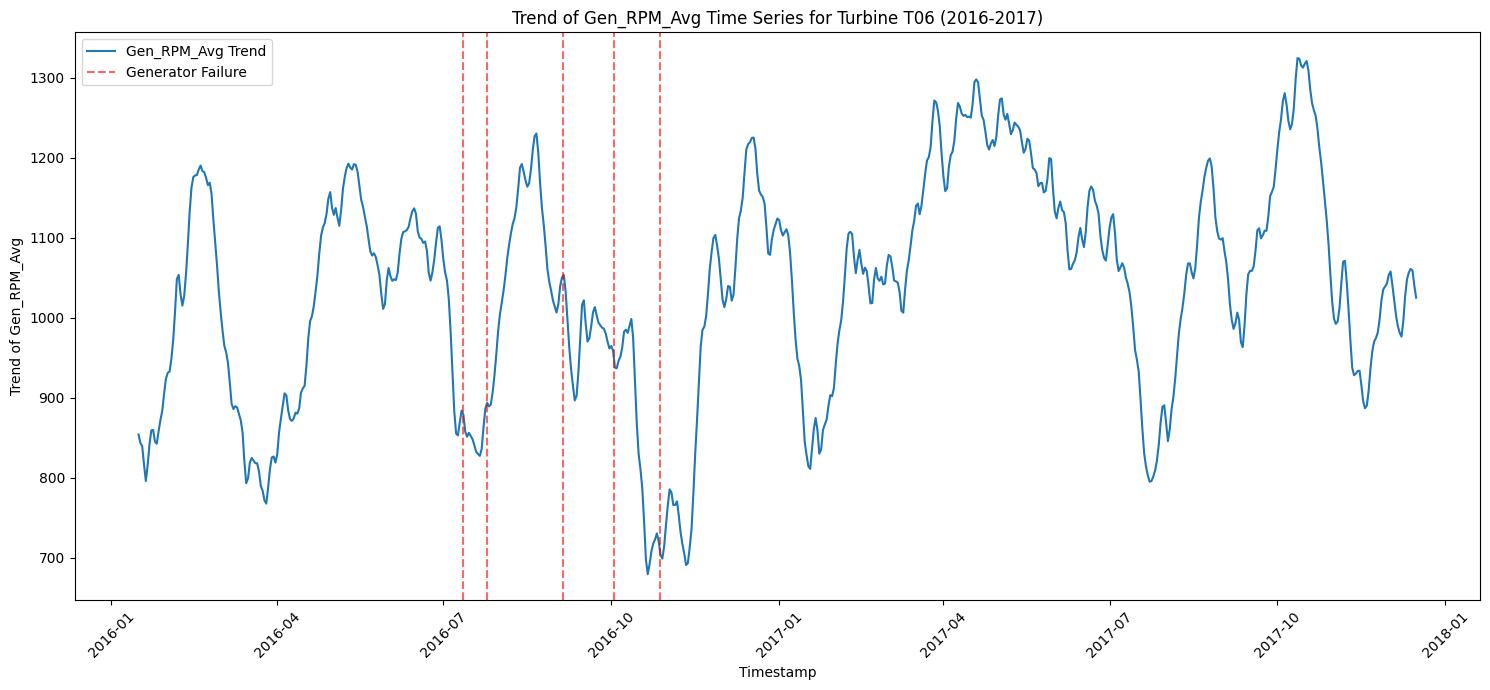

Saved plot for Gen_Bear_Temp_Avg to /content/drive/MyDrive/School projects/PFE Project/Datasets/artical_level_data_preparation/visualizations/TrendAnalysis_T06_Gen_Bear_Temp_Avg.png


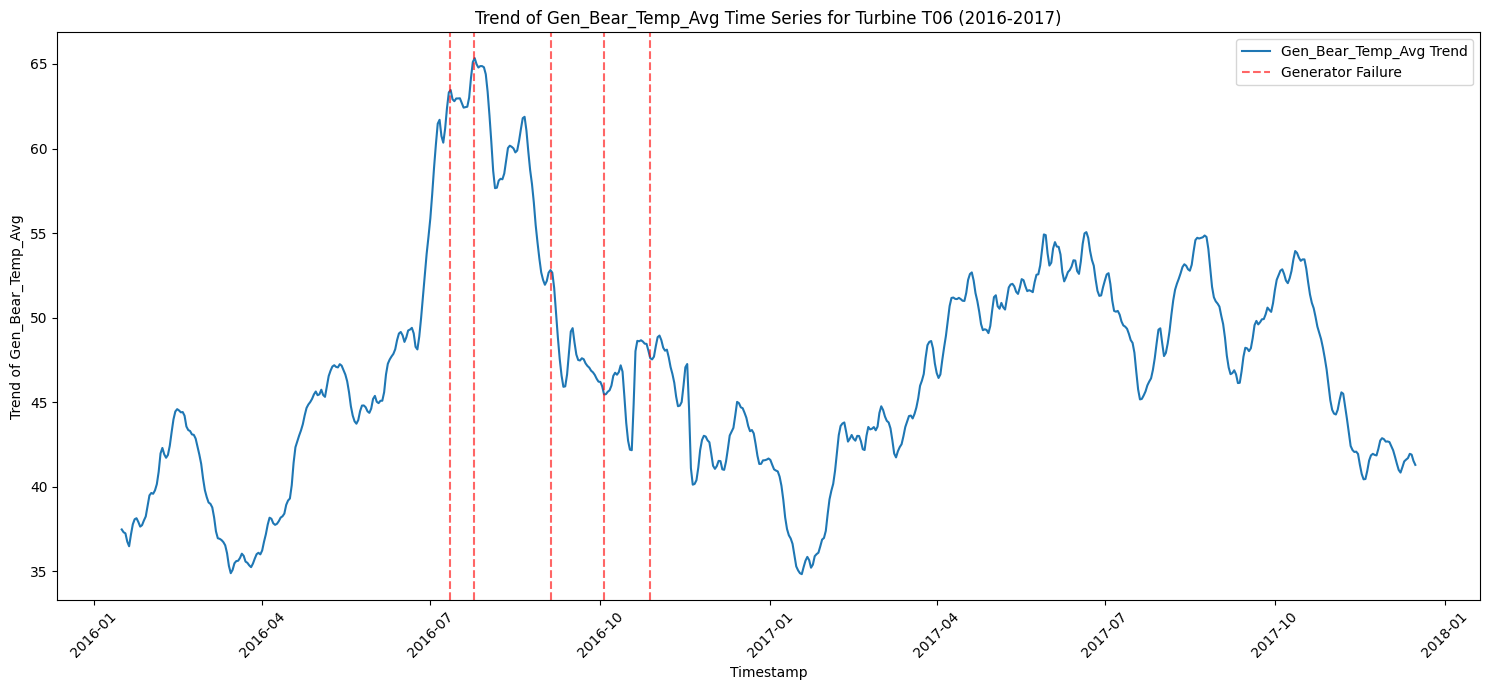

Saved plot for Gen_Phase1_Temp_Avg to /content/drive/MyDrive/School projects/PFE Project/Datasets/artical_level_data_preparation/visualizations/TrendAnalysis_T06_Gen_Phase1_Temp_Avg.png


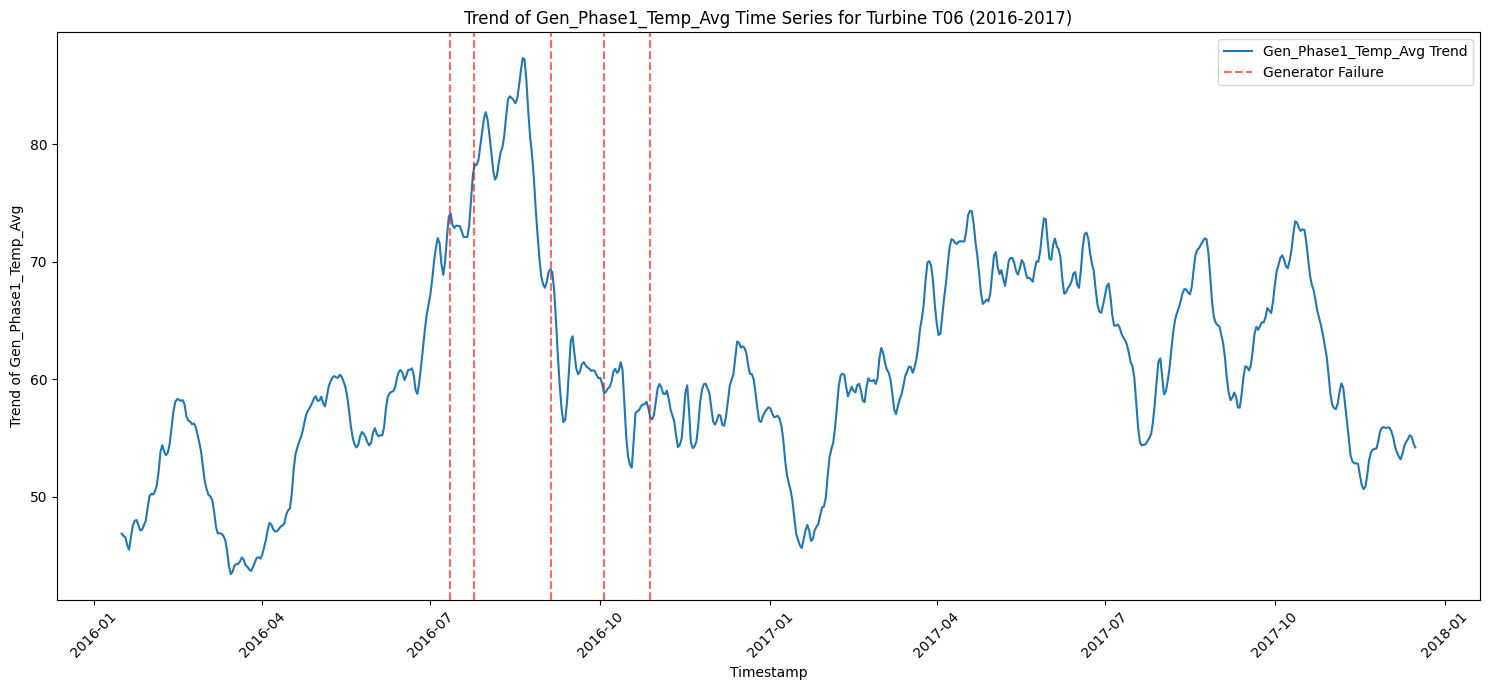

Saved plot for Gen_Phase2_Temp_Avg to /content/drive/MyDrive/School projects/PFE Project/Datasets/artical_level_data_preparation/visualizations/TrendAnalysis_T06_Gen_Phase2_Temp_Avg.png


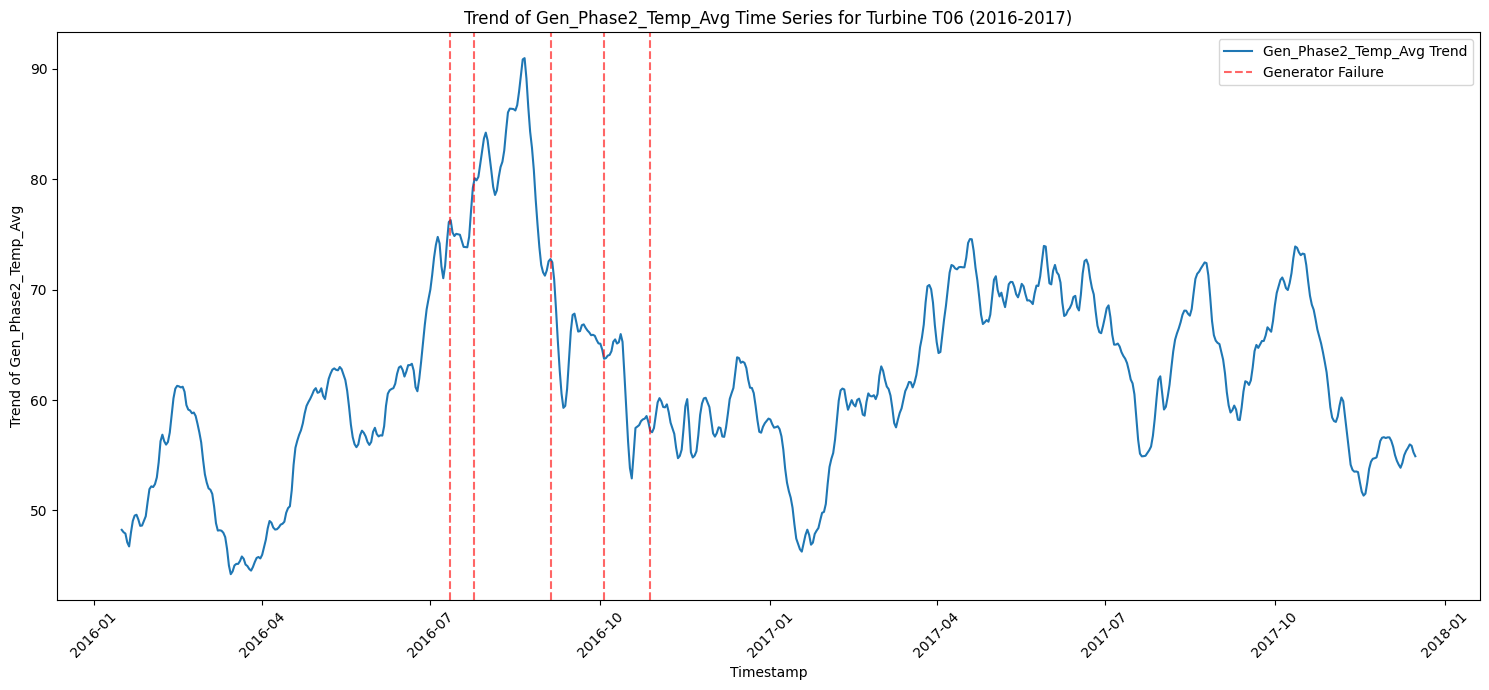

Saved plot for Gen_Phase3_Temp_Avg to /content/drive/MyDrive/School projects/PFE Project/Datasets/artical_level_data_preparation/visualizations/TrendAnalysis_T06_Gen_Phase3_Temp_Avg.png


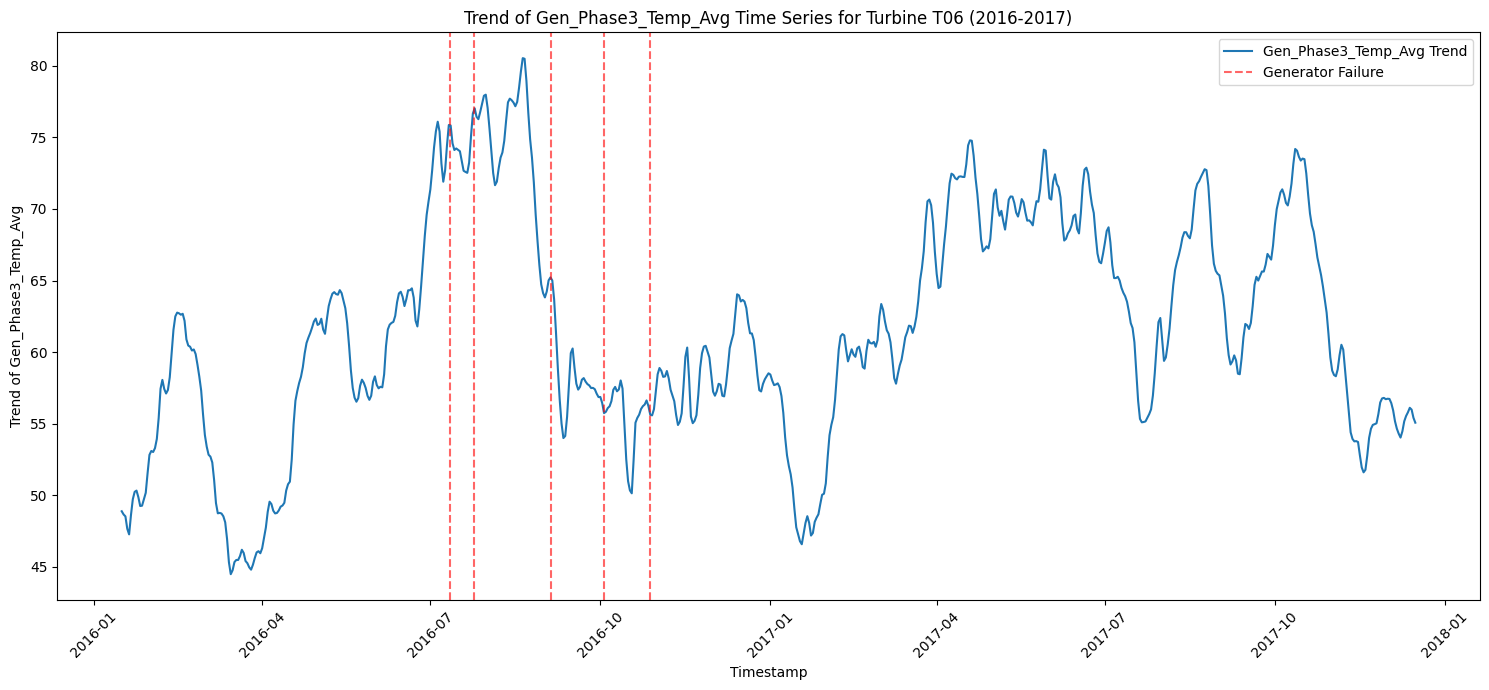

Saved plot for Hyd_Oil_Temp_Avg to /content/drive/MyDrive/School projects/PFE Project/Datasets/artical_level_data_preparation/visualizations/TrendAnalysis_T06_Hyd_Oil_Temp_Avg.png


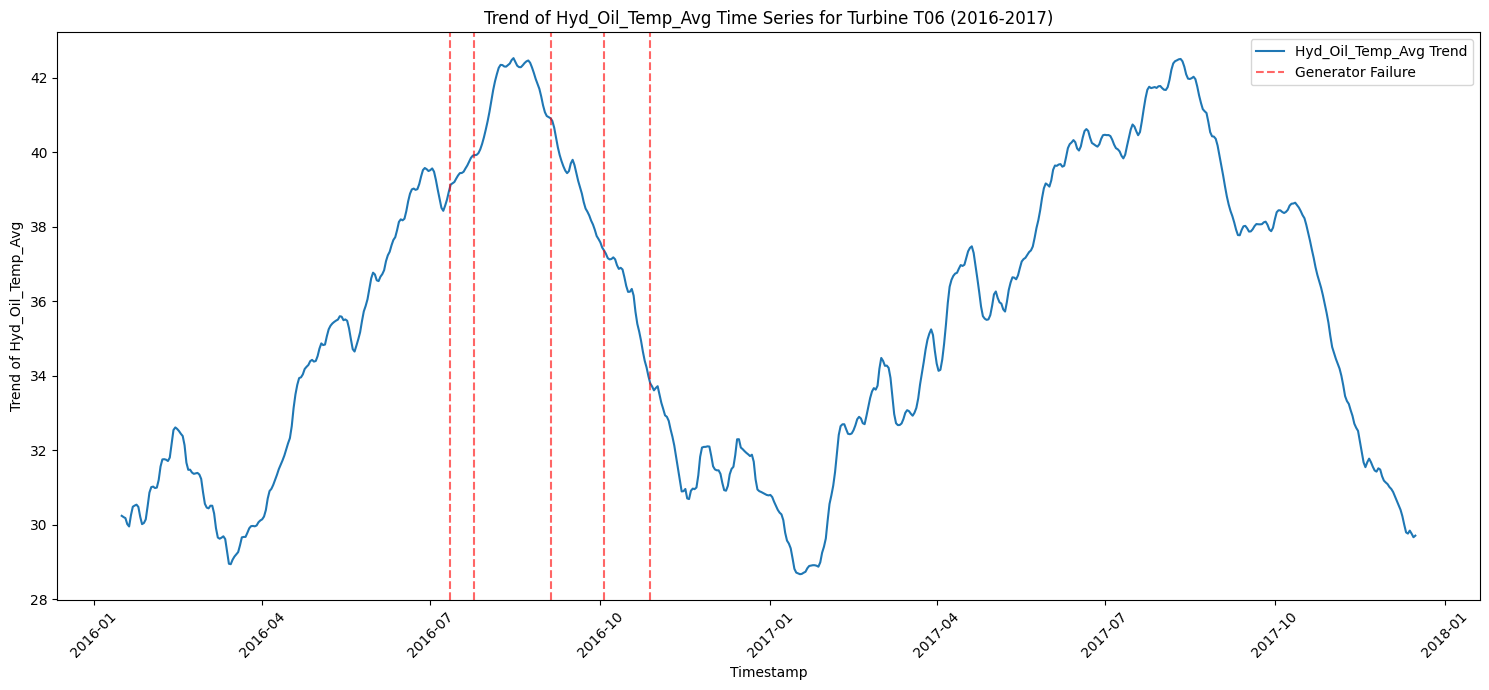

Saved plot for Nac_Temp_Avg to /content/drive/MyDrive/School projects/PFE Project/Datasets/artical_level_data_preparation/visualizations/TrendAnalysis_T06_Nac_Temp_Avg.png


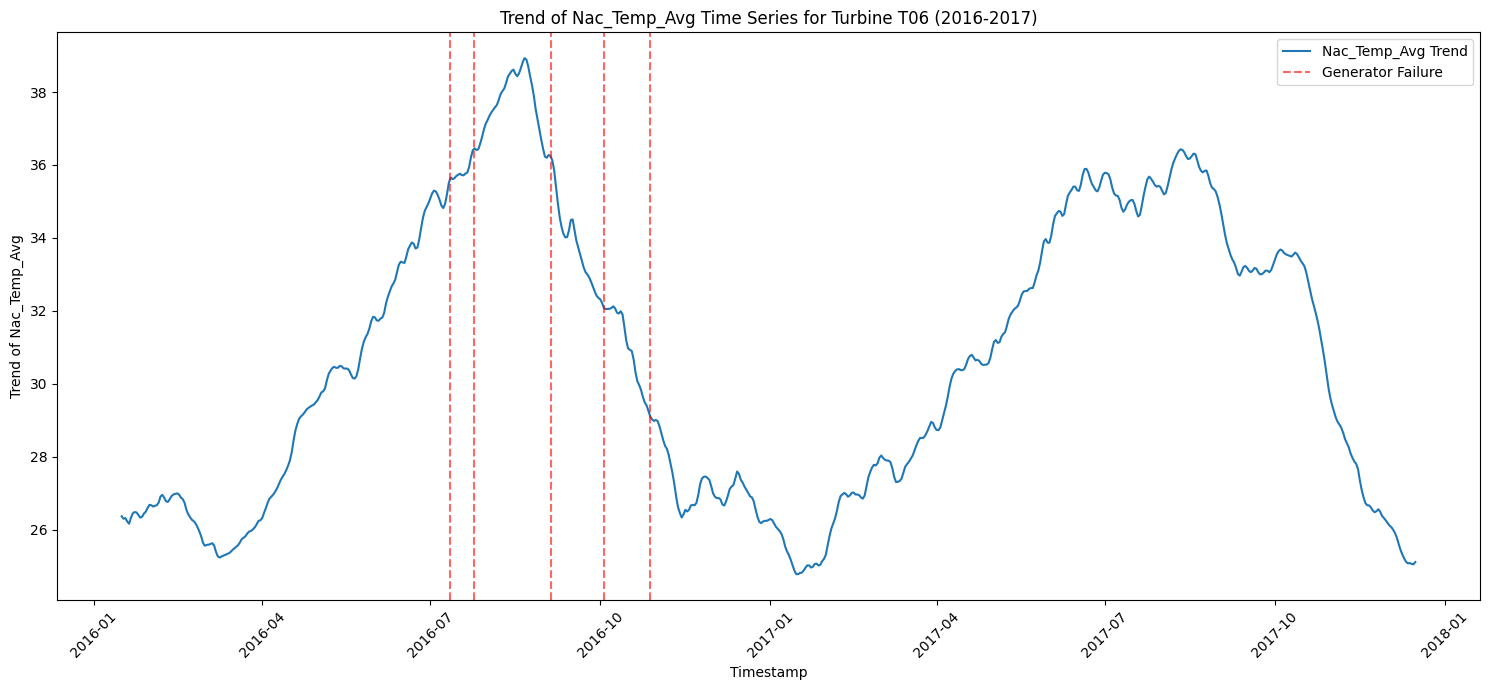

Saved plot for Amb_WindSpeed_Avg to /content/drive/MyDrive/School projects/PFE Project/Datasets/artical_level_data_preparation/visualizations/TrendAnalysis_T06_Amb_WindSpeed_Avg.png


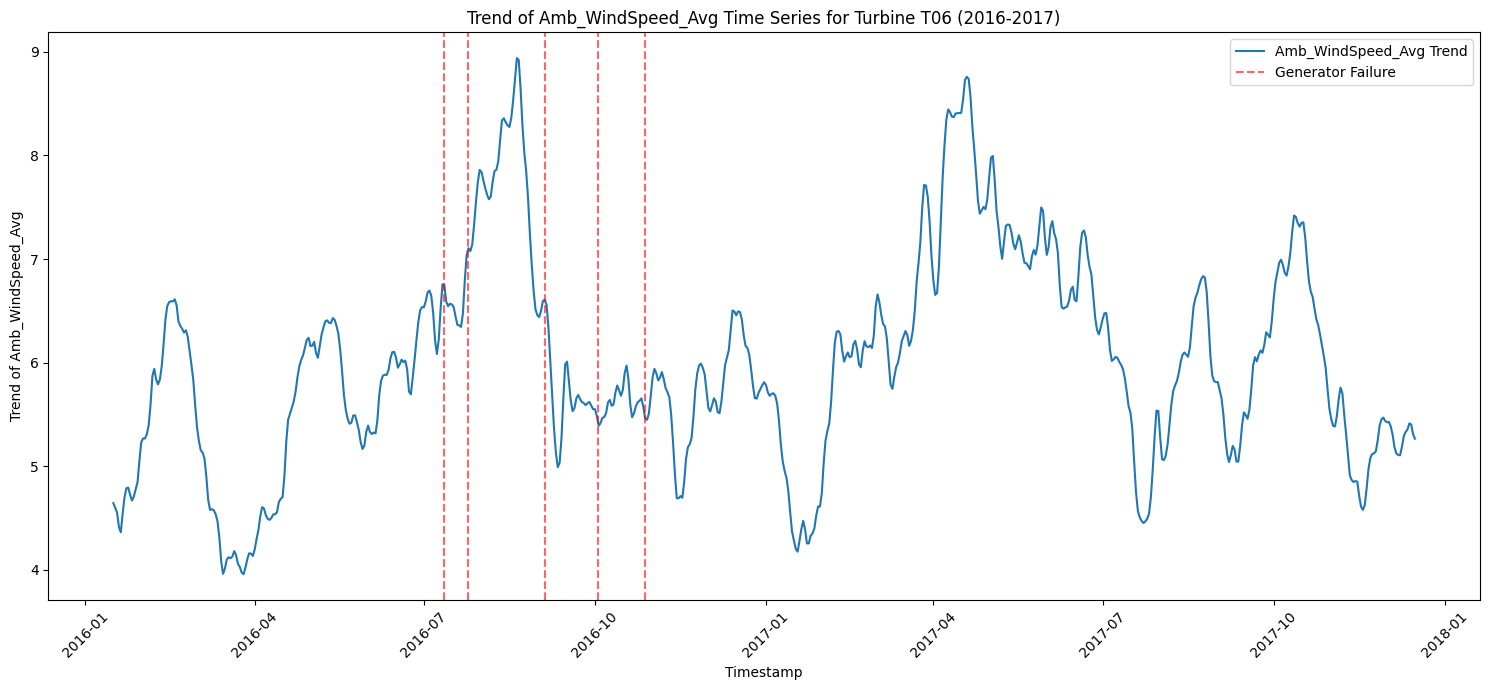

Saved plot for Amb_Temp_Avg to /content/drive/MyDrive/School projects/PFE Project/Datasets/artical_level_data_preparation/visualizations/TrendAnalysis_T06_Amb_Temp_Avg.png


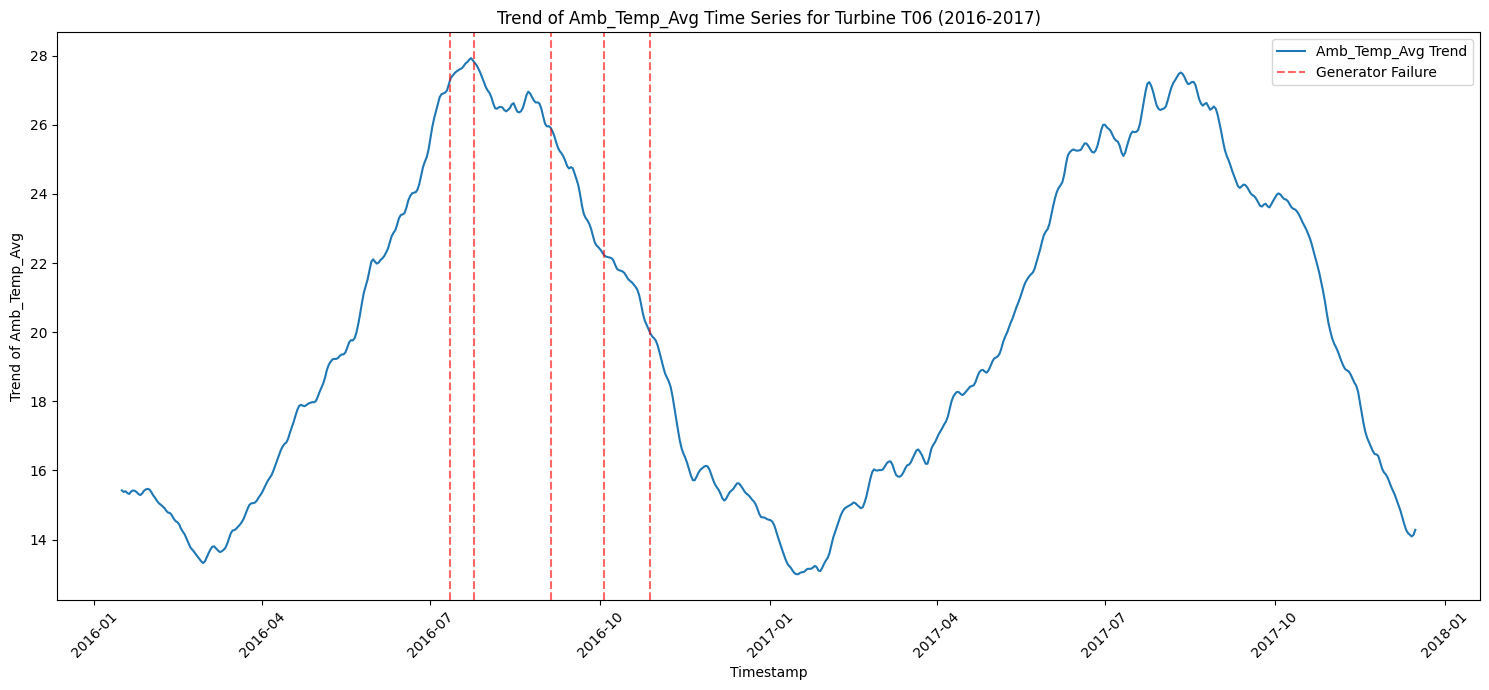

In [ ]:
# This code block plots the trend of major features for Turbine T06 over the two-year period,
# highlighting all generator failure timestamps for this turbine.

# Ensure 'scada_merged' and 'failure_logs_merged' DataFrames are available
if 'scada_merged' not in locals() or 'failure_logs_merged' not in locals():
    print("Error: 'scada_merged' or 'failure_logs_merged' DataFrames not found. Please run the data loading and merging steps.")
else:
    # Convert 'Timestamp' column to datetime if not already
    scada_merged['Timestamp'] = pd.to_datetime(scada_merged['Timestamp'])
    failure_logs_merged['Timestamp'] = pd.to_datetime(failure_logs_merged['Timestamp'])

    # 1. Select the specific turbine (T06)
    selected_turbine_id = 'T06'
    scada_selected_turbine = scada_merged[scada_merged['Turbine_ID'] == selected_turbine_id].copy()

    # 2. Filter failure logs for the selected turbine and 'GENERATOR' component
    generator_failures_turbine = failure_logs_merged[
        (failure_logs_merged['Turbine_ID'] == selected_turbine_id) &
        (failure_logs_merged['Component'] == 'GENERATOR')
    ].copy()

    # Extract the timestamps of the generator failures for this turbine
    failure_timestamps = generator_failures_turbine['Timestamp'].tolist()

    print(f"Analyzing Turbine: {selected_turbine_id}")
    print(f"Generator Failure Timestamps for {selected_turbine_id}: {failure_timestamps}")

    # 3. Identify major features/columns to plot
    # Excluding columns that are not suitable for time series plotting or are identifiers/labels
    # Based on common wind turbine SCADA analysis, these features are usually important.
    commonly_analyzed_features = [
        'Gen_RPM_Avg',
        'Gen_Bear_Temp_Avg',
        'Gen_Phase1_Temp_Avg',
        'Gen_Phase2_Temp_Avg',
        'Gen_Phase3_Temp_Avg',
        'Hyd_Oil_Temp_Avg',
        'Nac_Temp_Avg',
        'Amb_WindSpeed_Avg',
        'Amb_Temp_Avg',
        'Prod_P_Avg' # Including average active power if available and relevant
    ]

    # Filter commonly_analyzed_features to include only those present in the DataFrame and are numeric
    major_feature_columns_to_plot = [col for col in commonly_analyzed_features if col in scada_selected_turbine.columns and is_numeric_dtype(scada_selected_turbine[col])]


    print("Major feature columns selected for plotting trend:")
    print(major_feature_columns_to_plot)

    # 4. Generate time series trend plots for each major feature
    if not scada_selected_turbine.empty and major_feature_columns_to_plot:
        # Set 'Timestamp' as index for time series decomposition
        scada_selected_turbine = scada_selected_turbine.set_index('Timestamp')

        for feature in major_feature_columns_to_plot:
            ts_data = scada_selected_turbine[feature].dropna()

            # Resample the data to a lower frequency (e.g., daily) for smoother trend
            # Using 'D' for daily resampling
            ts_data_resampled = ts_data.resample('D').mean().interpolate()

            # Check if enough data points for decomposition after resampling
            min_data_points_for_decomp = 2 * 30 + 1 # Example: minimum for monthly seasonality
            if len(ts_data_resampled) > min_data_points_for_decomp:
                 try:
                    decomposition = seasonal_decompose(ts_data_resampled, model='additive', period=30)
                    trend_data = decomposition.trend.dropna()

                    plt.figure(figsize=(15, 7))
                    plt.plot(trend_data.index, trend_data.values, label=f'{feature} Trend')

                    # Add vertical lines for each failure timestamp
                    for failure_time in failure_timestamps:
                        plt.axvline(failure_time, color='red', linestyle='--', alpha=0.6, label='Generator Failure' if failure_time == failure_timestamps[0] else "") # Label only the first line

                    plt.title(f'Trend of {feature} Time Series for Turbine {selected_turbine_id} (2016-2017)')
                    plt.xlabel('Timestamp')
                    plt.ylabel(f'Trend of {feature}')
                    plt.xticks(rotation=45)
                    plt.legend()
                    plt.tight_layout()

                    # Generate a unique filename for each plot
                    filename = f"TrendAnalysis_{selected_turbine_id}_{feature}.png"
                    filepath = os.path.join(visualizations_path, filename)
                    plt.savefig(filepath)
                    print(f"Saved plot for {feature} to {filepath}")

                    plt.show()

                 except Exception as e:
                    print(f"Could not perform seasonal decomposition for {feature}: {e}")
                    print(f"Skipping trend plot for {feature}.")
            else:
                 print(f"Not enough data points after resampling for {feature} to perform seasonal decomposition with period=30. Skipping trend plot.")


    elif scada_selected_turbine.empty:
        print(f"Filtered DataFrame for Turbine {selected_turbine_id} is empty. Cannot generate plots.")
    else:
        print("No major feature columns selected for plotting.")

Analyzing Turbine: T06
Generator Failure Timestamps for T06: [Timestamp('2016-07-11 19:48:00+0000', tz='UTC'), Timestamp('2016-07-24 17:01:00+0000', tz='UTC'), Timestamp('2016-09-04 08:08:00+0000', tz='UTC'), Timestamp('2016-10-27 16:26:00+0000', tz='UTC'), Timestamp('2016-10-02 17:08:00+0000', tz='UTC')]
Major feature columns selected for plotting:
['Gen_RPM_Avg', 'Gen_Bear_Temp_Avg', 'Gen_Phase1_Temp_Avg', 'Gen_Phase2_Temp_Avg', 'Gen_Phase3_Temp_Avg', 'Hyd_Oil_Temp_Avg', 'Nac_Temp_Avg', 'Amb_WindSpeed_Avg', 'Amb_Temp_Avg']


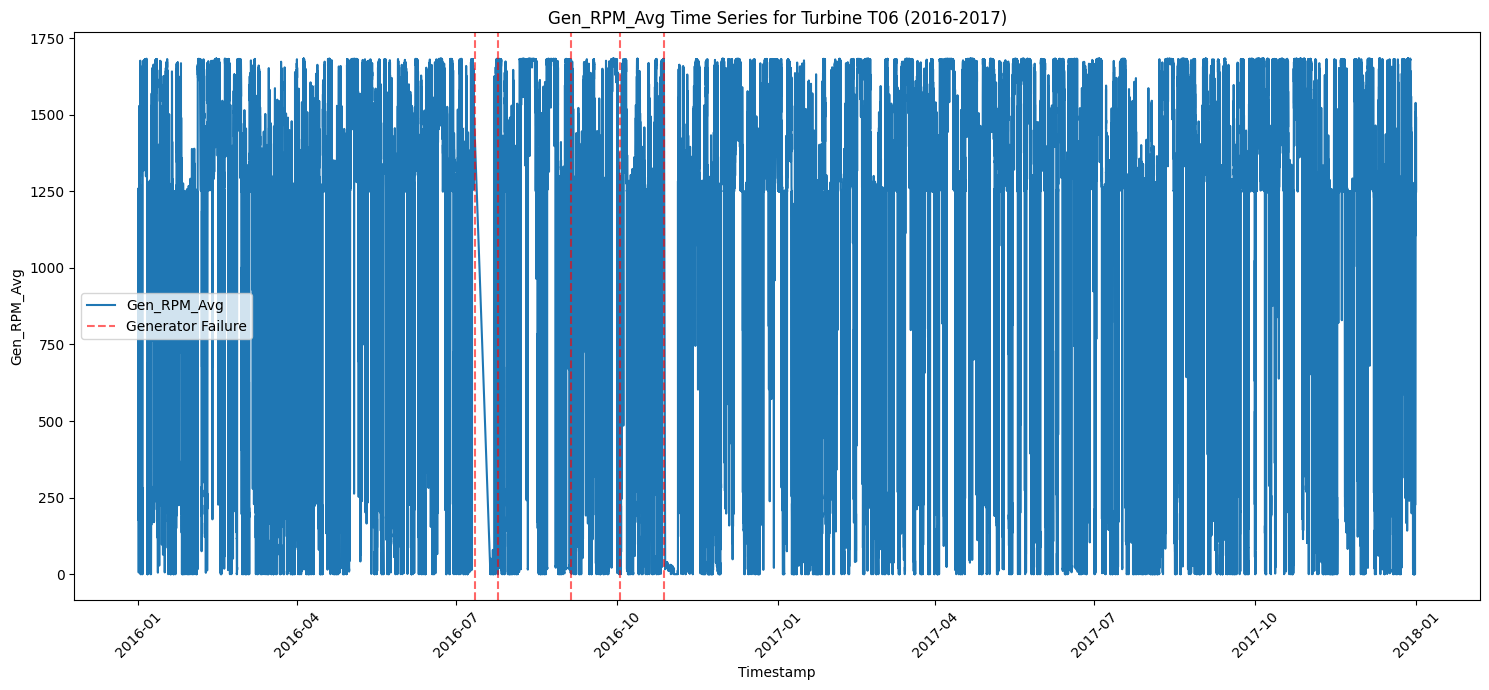

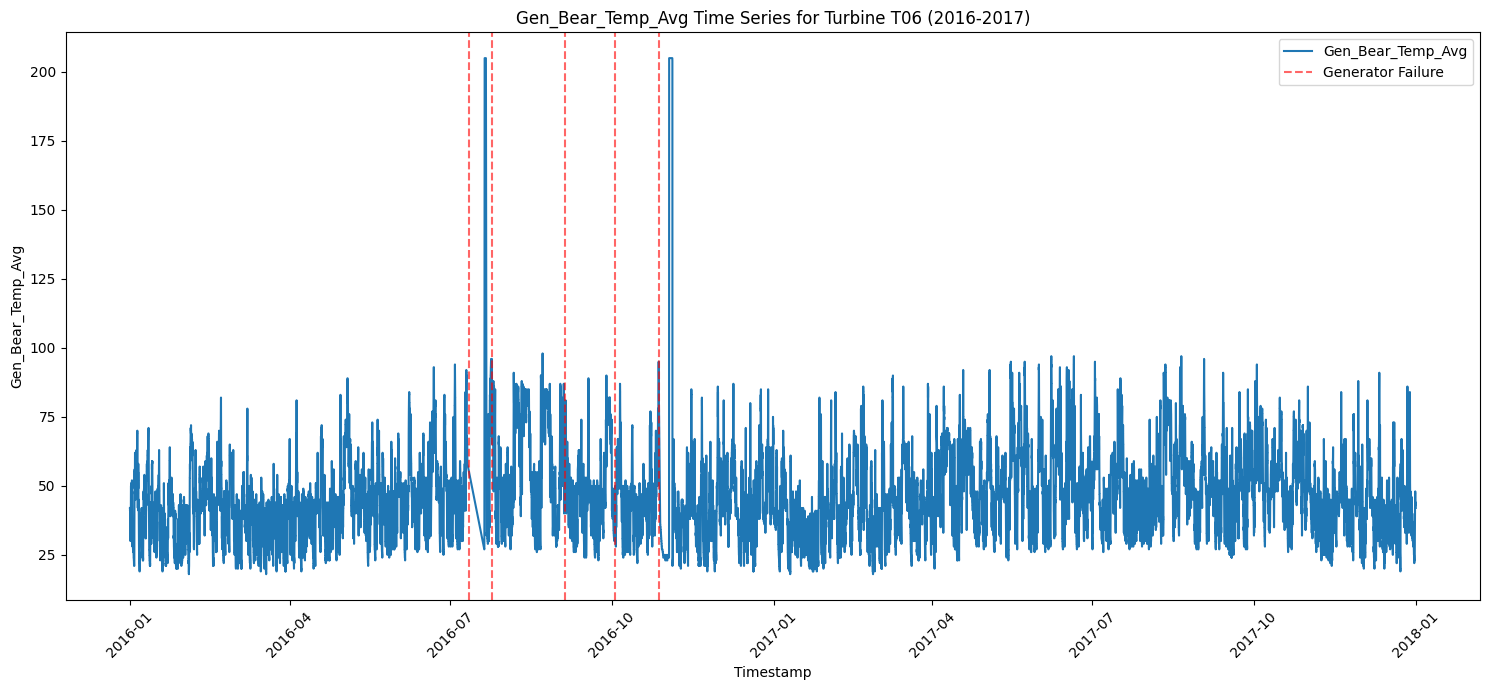

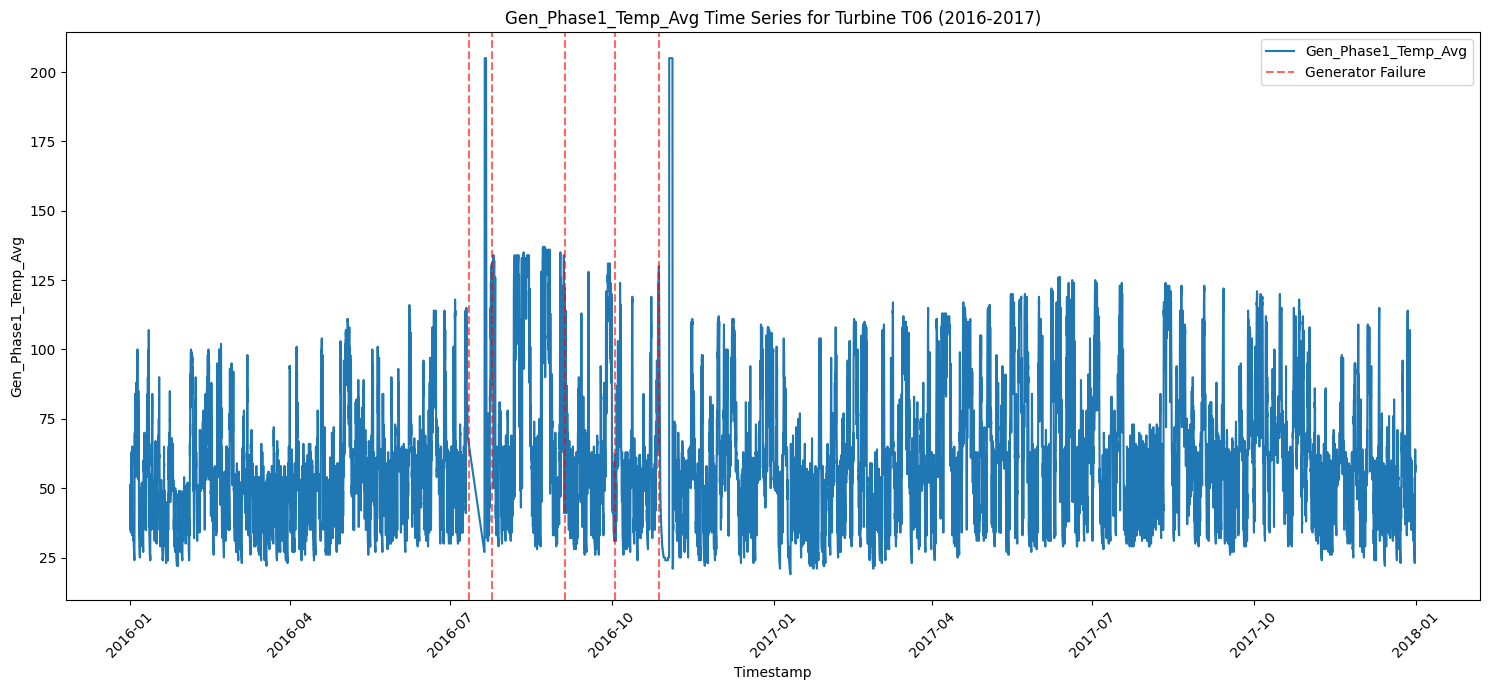

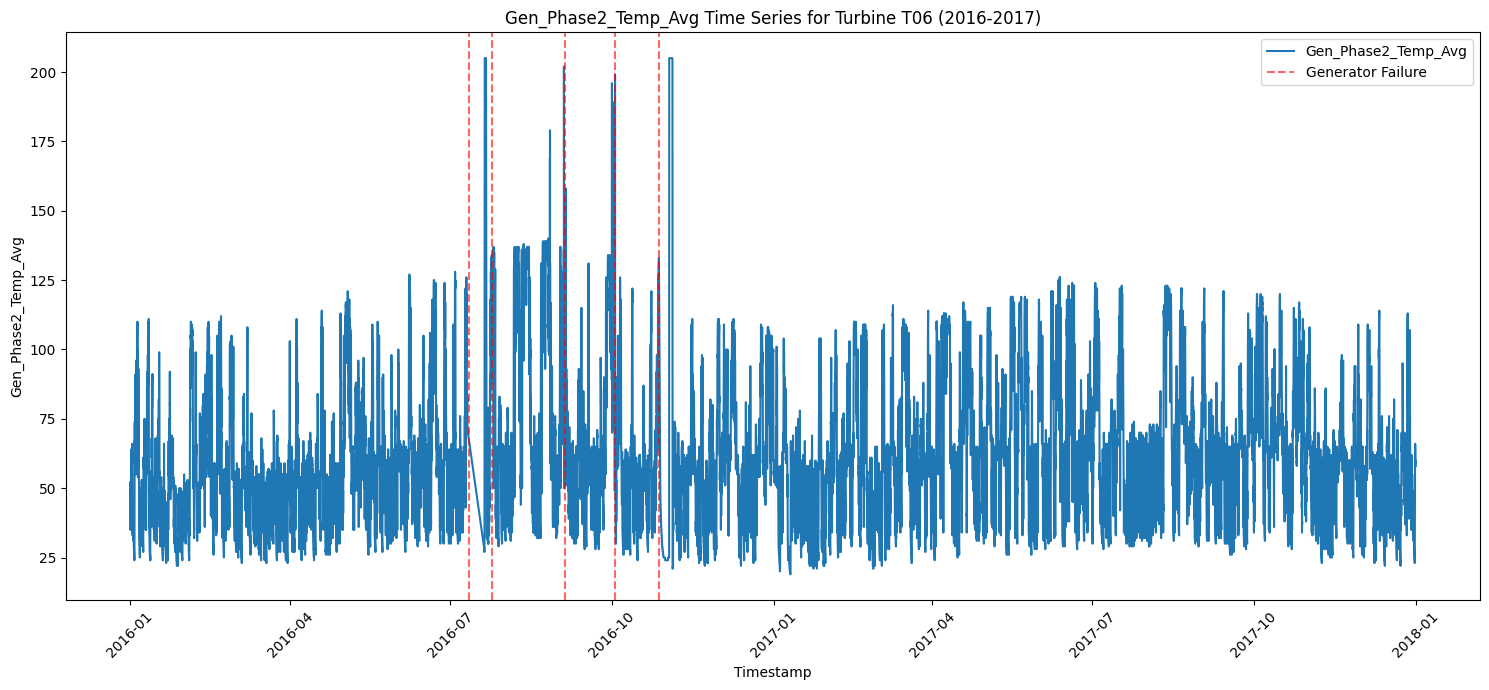

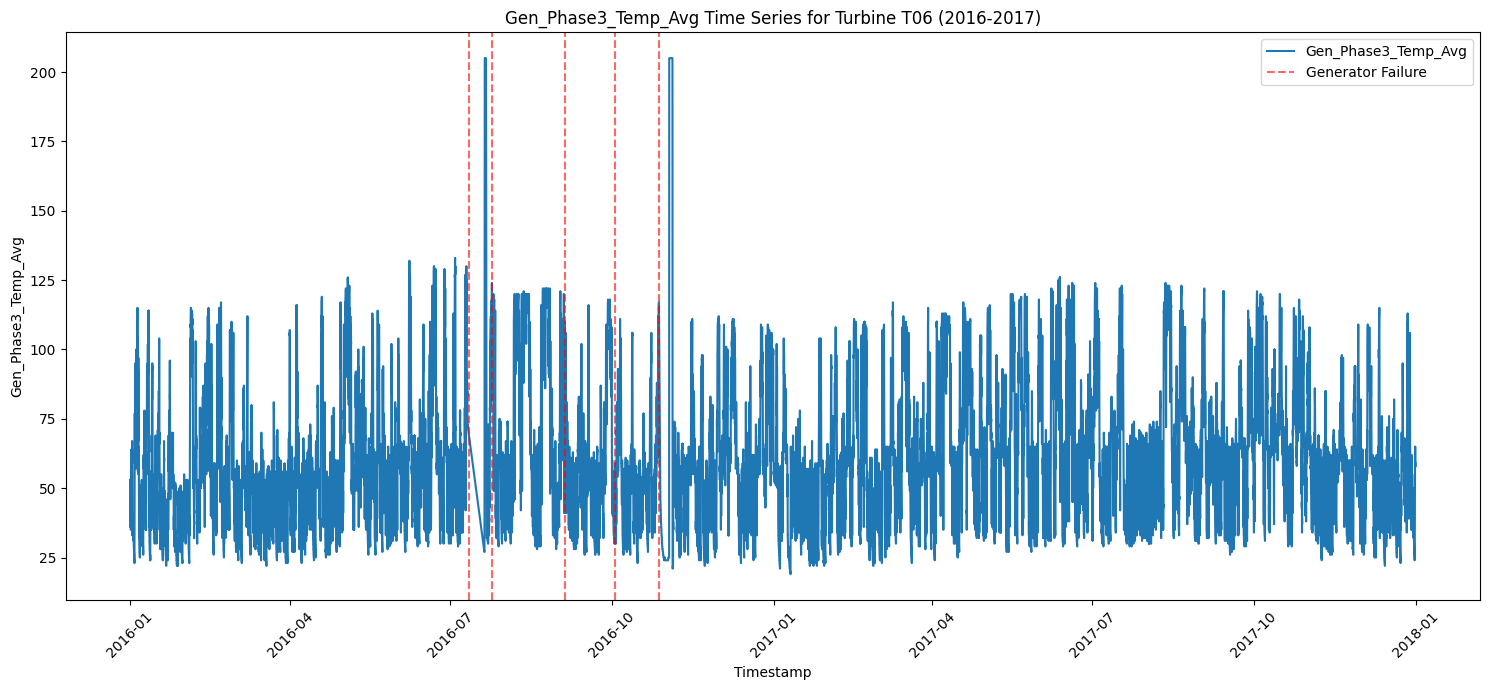

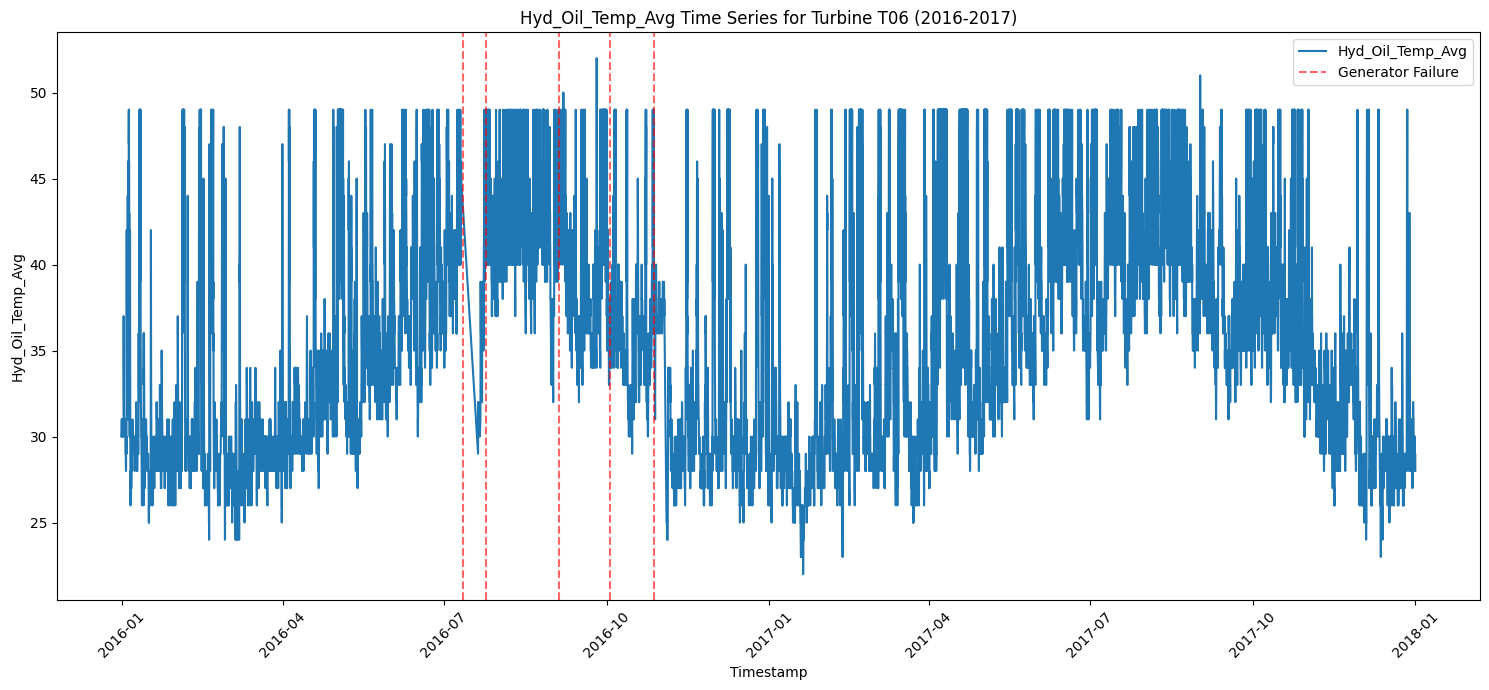

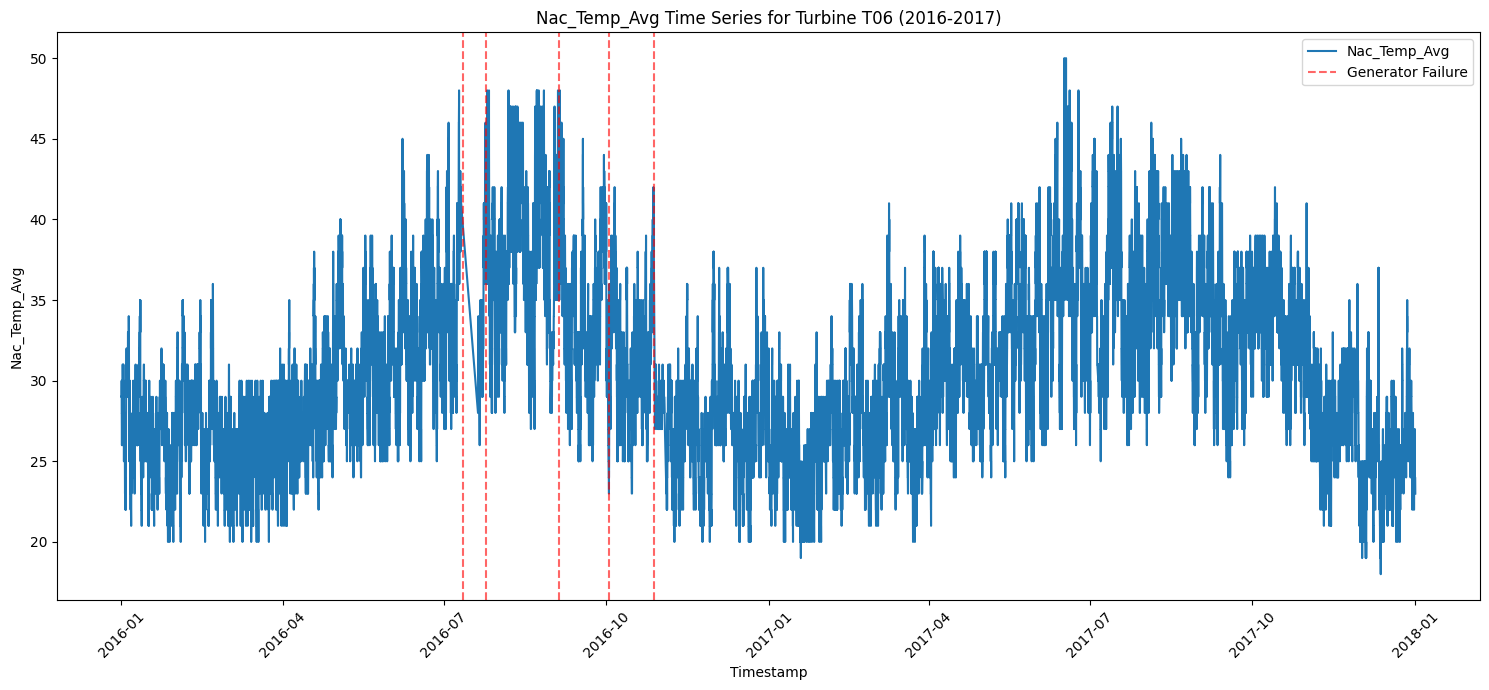

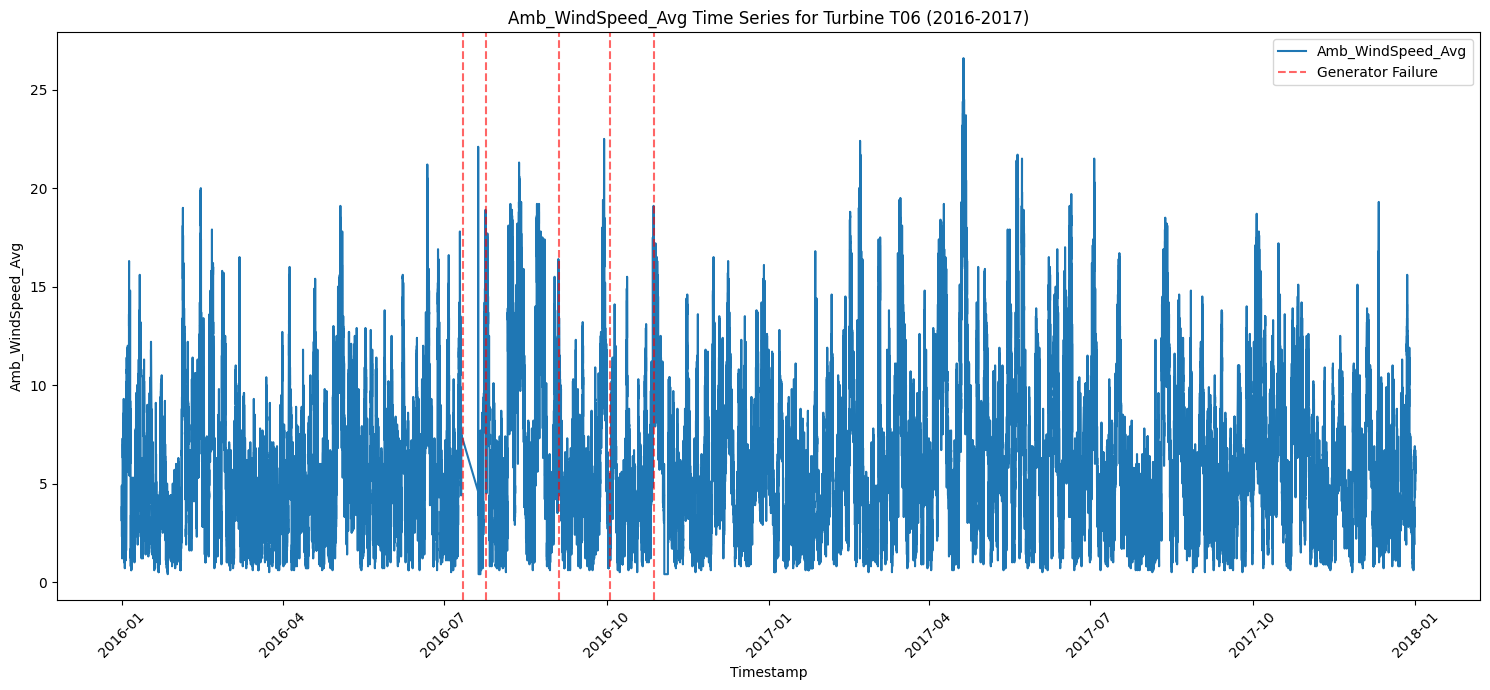

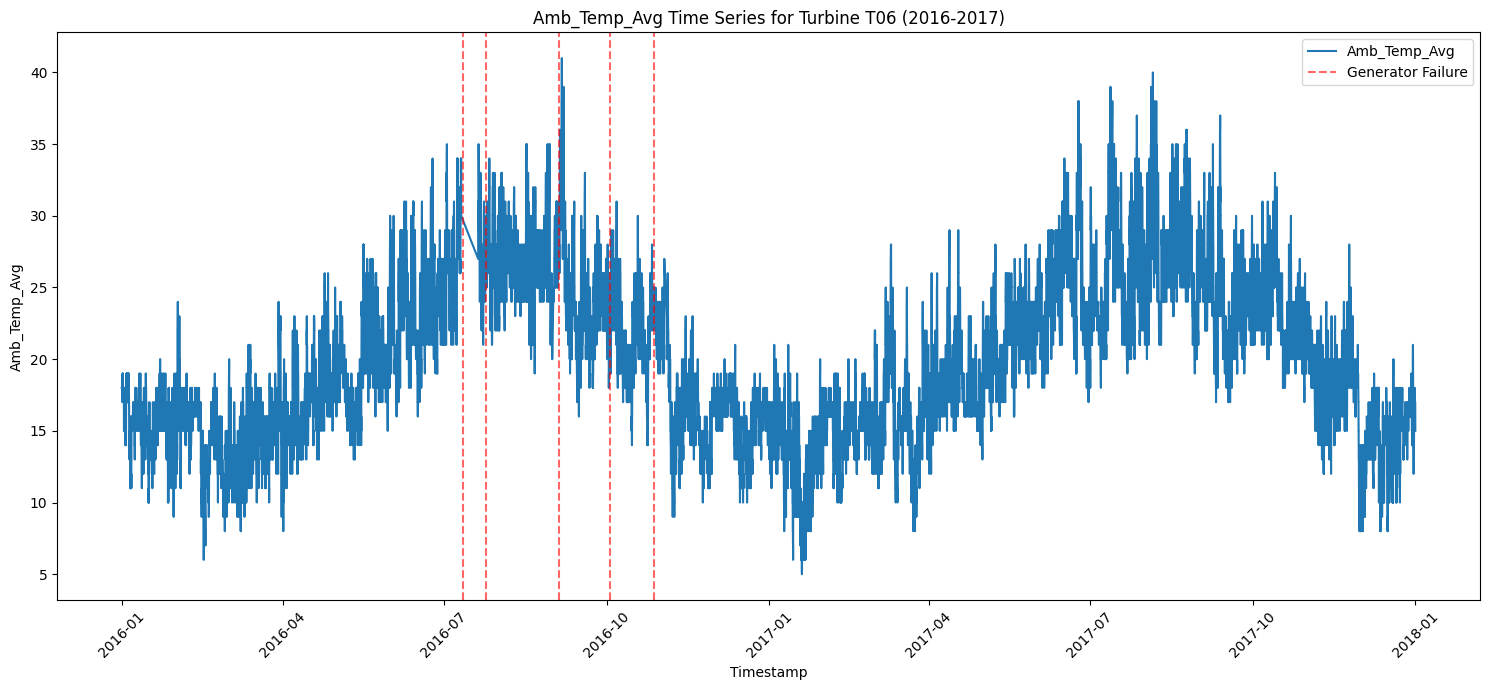

In [ ]:
# This code block plots major features for Turbine T06 over the two-year period,
# highlighting all generator failure timestamps for this turbine.

# Ensure 'scada_merged' and 'failure_logs_merged' DataFrames are available
if 'scada_merged' not in locals() or 'failure_logs_merged' not in locals():
    print("Error: 'scada_merged' or 'failure_logs_merged' DataFrames not found. Please run the data loading and merging steps.")
else:
    # Convert 'Timestamp' column to datetime if not already
    scada_merged['Timestamp'] = pd.to_datetime(scada_merged['Timestamp'])
    failure_logs_merged['Timestamp'] = pd.to_datetime(failure_logs_merged['Timestamp'])

    # 1. Select the specific turbine (T06)
    selected_turbine_id = 'T06'
    scada_selected_turbine = scada_merged[scada_merged['Turbine_ID'] == selected_turbine_id].copy()

    # 2. Filter failure logs for the selected turbine and 'GENERATOR' component
    generator_failures_turbine = failure_logs_merged[
        (failure_logs_merged['Turbine_ID'] == selected_turbine_id) &
        (failure_logs_merged['Component'] == 'GENERATOR')
    ].copy()

    # Extract the timestamps of the generator failures for this turbine
    failure_timestamps = generator_failures_turbine['Timestamp'].tolist()

    print(f"Analyzing Turbine: {selected_turbine_id}")
    print(f"Generator Failure Timestamps for {selected_turbine_id}: {failure_timestamps}")

    # 3. Identify major features/columns to plot
    # Excluding columns that are not suitable for time series plotting or are identifiers/labels
    major_feature_columns = [col for col in scada_selected_turbine.columns if col not in ['Timestamp', 'Turbine_ID', 'failure_label', 'Unnamed: 0']]

    # You might want to select a subset of these if there are too many
    # For this request, we'll plot all numerical columns except the identifiers and label.
    # Let's refine this list to focus on commonly analyzed SCADA parameters if the full list is too extensive.
    # Based on common wind turbine SCADA analysis, these features are usually important.
    commonly_analyzed_features = [
        'Gen_RPM_Avg',
        'Gen_Bear_Temp_Avg',
        'Gen_Phase1_Temp_Avg',
        'Gen_Phase2_Temp_Avg',
        'Gen_Phase3_Temp_Avg',
        'Hyd_Oil_Temp_Avg',
        'Nac_Temp_Avg',
        'Amb_WindSpeed_Avg',
        'Amb_Temp_Avg',
        'Prod_P_Avg' # Including average active power if available and relevant
    ]

    # Filter commonly_analyzed_features to include only those present in the DataFrame
    major_feature_columns_to_plot = [col for col in commonly_analyzed_features if col in scada_selected_turbine.columns]

    print("Major feature columns selected for plotting:")
    print(major_feature_columns_to_plot)

    # 4. Generate time series plots for each major feature
    if not scada_selected_turbine.empty and major_feature_columns_to_plot:
        for feature in major_feature_columns_to_plot:
            plt.figure(figsize=(15, 7))
            plt.plot(scada_selected_turbine['Timestamp'], scada_selected_turbine[feature], label=feature)

            # Add vertical lines for each failure timestamp
            for failure_time in failure_timestamps:
                plt.axvline(failure_time, color='red', linestyle='--', alpha=0.6, label='Generator Failure' if failure_time == failure_timestamps[0] else "") # Label only the first line

            plt.title(f'{feature} Time Series for Turbine {selected_turbine_id} (2016-2017)')
            plt.xlabel('Timestamp')
            plt.ylabel(feature)
            plt.xticks(rotation=45)
            plt.legend()
            plt.tight_layout()
            plt.savefig(os.path.join(visualizations_path,f"TSA_TO6_Generator_{feature}.png"))
            plt.show()
    elif scada_selected_turbine.empty:
        print(f"Filtered DataFrame for Turbine {selected_turbine_id} is empty. Cannot generate plots.")
    else:
        print("No major feature columns selected for plotting.")

# Post-Failure window Determination

POST-FAILURE WINDOW ANALYSIS WORKFLOW

Step 1: Initializing analyzer...

Step 2: Analyzing recovery periods...
Analyzing post-failure recovery periods...

Analyzing: T01 - GEARBOX - 2016-07-18 02:10:00+00:00
  ✓ Recovery detected after 41.7 hours

Analyzing: T06 - GENERATOR - 2016-07-11 19:48:00+00:00
  ✗ No clear recovery detected

Analyzing: T06 - GENERATOR - 2016-07-24 17:01:00+00:00
  ✓ Recovery detected after 41.8 hours

Analyzing: T06 - GENERATOR - 2016-09-04 08:08:00+00:00
  ✓ Recovery detected after 3.5 hours

Analyzing: T06 - GENERATOR - 2016-10-27 16:26:00+00:00
  ✗ No clear recovery detected

Analyzing: T06 - GENERATOR - 2016-10-02 17:08:00+00:00
  ✓ Recovery detected after 3.9 hours

Analyzing: T06 - HYDRAULIC_GROUP - 2016-04-04 18:53:00+00:00
  ✓ Recovery detected after 11.4 hours

Analyzing: T07 - GENERATOR_BEARING - 2016-04-30 12:40:00+00:00
  ✓ Recovery detected after 4.3 hours

Analyzing: T07 - TRANSFORMER - 2016-07-10 03:46:00+00:00
  ✓ Recovery detected after 21.2 ho

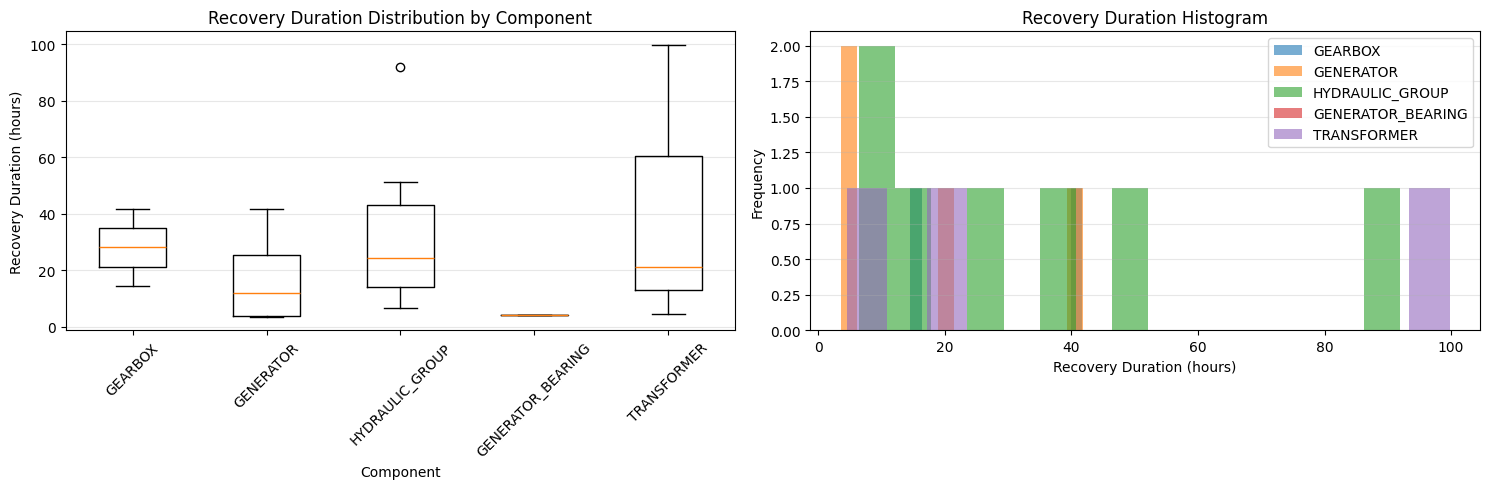


Step 5: Exporting recommendations...

ANALYSIS COMPLETE


TypeError: '>=' not supported between instances of 'str' and 'Timestamp'

In [ ]:
"""
Post-Failure Window Analysis for Wind Turbine SCADA Data
Determines optimal post-failure windows for different component types
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. POST-FAILURE WINDOW DETECTION
# ============================================================================

class PostFailureAnalyzer:
    """
    Analyzes post-failure patterns to determine optimal recovery windows
    """

    def __init__(self, data, failures, timestamp_col='Timestamp'):
        """
        Parameters:
        - data: preprocessed SCADA data
        - failures: failure logbook dataframe
        - timestamp_col: name of timestamp column
        """
        self.data = data.copy()
        self.failures = failures.copy()
        self.timestamp_col = timestamp_col

        # Ensure timestamp is datetime
        self.data[timestamp_col] = pd.to_datetime(self.data[timestamp_col])
        self.failures[timestamp_col] = pd.to_datetime(self.failures[timestamp_col])

    def detect_recovery_period(self, turbine_id, failure_time,
                               key_signals=['Gen_RPM_Avg', 'Power_avg', 'Wind_Speed_avg'],
                               max_window_hours=168):  # 7 days
        """
        Detect when turbine returns to normal operation after failure

        Parameters:
        - turbine_id: turbine identifier
        - failure_time: timestamp of failure occurrence
        - key_signals: signals to monitor for recovery
        - max_window_hours: maximum hours to search for recovery

        Returns:
        - recovery_metrics: detailed recovery analysis (dictionary)
        """

        # Filter data for specific turbine
        turbine_data = self.data[self.data['Turbine_ID'] == turbine_id].copy()
        turbine_data = turbine_data.sort_values(self.timestamp_col)

        # Get pre-failure baseline (30 days before failure)
        pre_failure_start = failure_time - timedelta(days=60)
        pre_failure_end = failure_time - timedelta(hours=24)  # 1 day before

        baseline_data = turbine_data[
            (turbine_data[self.timestamp_col] >= pre_failure_start) &
            (turbine_data[self.timestamp_col] <= pre_failure_end)
        ]

        # Get post-failure data
        post_failure_end = failure_time + timedelta(hours=max_window_hours)
        post_failure_data = turbine_data[
            (turbine_data[self.timestamp_col] > failure_time) &
            (turbine_data[self.timestamp_col] <= post_failure_end)
        ]

        if len(baseline_data) == 0 or len(post_failure_data) == 0:
            return {
                'recovery_detected': False,
                'recovery_timestamp': None,
                'recovery_duration_hours': None,
                'failure_time': failure_time,
                'baseline_stats': {}
            }

        # Calculate baseline statistics
        baseline_stats = {}
        for signal in key_signals:
            if signal in baseline_data.columns:
                # Filter for operational periods (e.g., power > 0)
                operational_mask = baseline_data[signal] > 0
                if operational_mask.sum() > 0:
                    baseline_stats[signal] = {
                        'mean': baseline_data.loc[operational_mask, signal].mean(),
                        'std': baseline_data.loc[operational_mask, signal].std(),
                        'q25': baseline_data.loc[operational_mask, signal].quantile(0.25),
                        'q75': baseline_data.loc[operational_mask, signal].quantile(0.75)
                    }

        # Detect recovery point
        recovery_metrics = self._detect_recovery_point(
            post_failure_data, baseline_stats, key_signals, failure_time
        )

        return recovery_metrics

    def _detect_recovery_point(self, post_data, baseline_stats, signals, failure_time):
        """
        Internal method to detect when signals return to baseline
        """
        recovery_detected = False
        recovery_timestamp = None
        recovery_duration_hours = None

        # Method 1: Consecutive stable periods
        # Look for 6+ hours of consecutive operation within baseline range
        stable_window_hours = 6
        stable_window_points = int(stable_window_hours * 6)  # 10-min intervals

        for signal in signals:
            if signal not in baseline_stats or signal not in post_data.columns:
                continue

            baseline = baseline_stats[signal]

            # Define recovery threshold (within 1 std of mean)
            lower_threshold = baseline['mean'] - baseline['std']
            upper_threshold = baseline['mean'] + baseline['std']

            # Check each point
            post_data['within_baseline'] = (
                (post_data[signal] >= lower_threshold) &
                (post_data[signal] <= upper_threshold) &
                (post_data[signal] > 0)  # Must be operational
            )

            # Find first occurrence of stable_window_points consecutive True values
            post_data['rolling_stability'] = (
                post_data['within_baseline']
                .rolling(window=stable_window_points, min_periods=stable_window_points)
                .sum()
            )

            stable_periods = post_data[post_data['rolling_stability'] == stable_window_points]

            if len(stable_periods) > 0:
                potential_recovery = stable_periods.iloc[0][self.timestamp_col]

                if recovery_timestamp is None or potential_recovery < recovery_timestamp:
                    recovery_timestamp = potential_recovery
                    recovery_detected = True

        # Method 2: Zero output detection (turbine completely stopped)
        # Find when turbine starts producing power again consistently
        if 'Power_avg' in post_data.columns:
            # Find gaps where power is zero
            post_data['power_zero'] = post_data['Power_avg'] <= 10  # Near zero
            post_data['zero_period_id'] = (
                post_data['power_zero'] != post_data['power_zero'].shift()
            ).cumsum()

            # Get first zero period after failure
            zero_periods = post_data[post_data['power_zero']].groupby('zero_period_id')

            if len(zero_periods) > 0:
                # Find the first group that starts after the failure time
                first_zero_period_group = None
                for group_id, group_data in zero_periods:
                    if group_data[self.timestamp_col].iloc[0] > failure_time:
                        first_zero_period_group = group_data
                        break

                if first_zero_period_group is not None:
                    # Find end of zero period
                    zero_end_idx = first_zero_period_group.index[-1]

                    if zero_end_idx < len(post_data) - 1:
                        zero_period_end = post_data.loc[post_data.index[post_data.index.get_loc(zero_end_idx) + 1], self.timestamp_col]

                        # This could be the start of recovery
                        if not recovery_detected or zero_period_end < recovery_timestamp:
                            recovery_timestamp = zero_period_end
                            recovery_detected = True


        if recovery_timestamp:
            recovery_duration_hours = (
                recovery_timestamp - failure_time
            ).total_seconds() / 3600

        return {
            'recovery_detected': recovery_detected,
            'recovery_timestamp': recovery_timestamp,
            'recovery_duration_hours': recovery_duration_hours,
            'failure_time': failure_time,
            'baseline_stats': baseline_stats
        }


    def analyze_all_failures(self, key_signals=['Gen_RPM_Avg', 'Power_avg']):
        """
        Analyze recovery periods for all failures in the logbook
        """
        print("Analyzing post-failure recovery periods...")
        print("=" * 70)

        results = []

        for idx, failure in self.failures.iterrows():
            turbine_id = failure['Turbine_ID']
            component = failure['Component']
            failure_time = failure['Timestamp']

            print(f"\nAnalyzing: {turbine_id} - {component} - {failure_time}")

            metrics = self.detect_recovery_period(
                turbine_id, failure_time, key_signals
            )

            # Check if metrics is a dictionary and recovery was detected
            if isinstance(metrics, dict) and metrics.get('recovery_detected', False):
                result = {
                    'Turbine_ID': turbine_id,
                    'Component': component,
                    'Failure_Time': failure_time,
                    'Recovery_Time': metrics['recovery_timestamp'],
                    'Recovery_Duration_Hours': metrics['recovery_duration_hours'],
                    'Recovery_Duration_Days': metrics['recovery_duration_hours'] / 24
                }
                results.append(result)

                print(f"  ✓ Recovery detected after {result['Recovery_Duration_Hours']:.1f} hours")
            else:
                print(f"  ✗ No clear recovery detected")

        results_df = pd.DataFrame(results)

        return results_df

    def calculate_component_windows(self, recovery_results):
        """
        Calculate recommended post-failure windows by component type
        """
        print("\n" + "=" * 70)
        print("POST-FAILURE WINDOW RECOMMENDATIONS BY COMPONENT")
        print("=" * 70)

        component_stats = recovery_results.groupby('Component').agg({
            'Recovery_Duration_Hours': ['mean', 'median', 'std', 'min', 'max', 'count']
        }).round(2)

        recommendations = {}

        for component in component_stats.index:
            stats = component_stats.loc[component, 'Recovery_Duration_Hours']

            # Recommendation: Use 75th percentile or mean + 1 std, whichever is higher
            recovery_times = recovery_results[
                recovery_results['Component'] == component
            ]['Recovery_Duration_Hours']

            percentile_75 = recovery_times.quantile(0.75)
            mean_plus_std = stats['mean'] + stats['std']

            recommended_window = max(percentile_75, mean_plus_std)

            # Round up to nearest 12 hours
            recommended_window = np.ceil(recommended_window / 12) * 12

            recommendations[component] = {
                'mean_hours': stats['mean'],
                'median_hours': stats['median'],
                'std_hours': stats['std'],
                'min_hours': stats['min'],
                'max_hours': stats['max'],
                'count': int(stats['count']),
                'percentile_75_hours': percentile_75,
                'recommended_window_hours': recommended_window,
                'recommended_window_days': recommended_window / 24
            }

            print(f"\n{component}:")
            print(f"  Samples analyzed: {int(stats['count'])}")
            print(f"  Mean recovery: {stats['mean']:.1f} hours ({stats['mean']/24:.1f} days)")
            print(f"  Median recovery: {stats['median']:.1f} hours ({stats['median']/24:.1f} days)")
            print(f"  Range: {stats['min']:.1f} - {stats['max']:.1f} hours")
            print(f"  ✓ RECOMMENDED WINDOW: {recommended_window:.0f} hours ({recommended_window/24:.1f} days)")

        return pd.DataFrame(recommendations).T

# ============================================================================
# 2. VISUALIZATION FUNCTIONS
# ============================================================================

def visualize_failure_recovery(data, failure_time, recovery_time,
                               turbine_id, component,
                               signals=['Gen_RPM_Avg', 'Power_avg', 'Wind_Speed_avg'],
                               window_days_before=7, window_days_after=14):
    """
    Visualize the failure and recovery period
    """
    # Filter data
    start_time = failure_time - timedelta(days=window_days_before)
    end_time = failure_time + timedelta(days=window_days_after)

    plot_data = data[
        (data['Turbine_ID'] == turbine_id) &
        (data['Timestamp'] >= start_time) &
        (data['Timestamp'] <= end_time)
    ].copy()

    # Create figure
    n_signals = len([s for s in signals if s in plot_data.columns])
    fig, axes = plt.subplots(n_signals, 1, figsize=(15, 4*n_signals))

    if n_signals == 1:
        axes = [axes]

    plot_idx = 0
    for signal in signals:
        if signal not in plot_data.columns:
            continue

        ax = axes[plot_idx]

        # Plot signal
        ax.plot(plot_data['Timestamp'], plot_data[signal],
                linewidth=0.8, alpha=0.8, label=signal)

        # Mark failure
        ax.axvline(failure_time, color='red', linestyle='--',
                   linewidth=2, label='Failure', alpha=0.7)

        # Mark recovery
        if recovery_time:
            ax.axvline(recovery_time, color='green', linestyle='--',
                       linewidth=2, label='Recovery', alpha=0.7)

            # Shade post-failure window
            ax.axvspan(failure_time, recovery_time,
                      alpha=0.2, color='orange', label='Post-Failure Window')

        ax.set_ylabel(signal)
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)

        plot_idx += 1

    axes[-1].set_xlabel('Timestamp')

    title = f'{turbine_id} - {component} Failure Recovery Analysis'
    if recovery_time:
        duration = (recovery_time - failure_time).total_seconds() / 3600
        title += f'\nRecovery Duration: {duration:.1f} hours ({duration/24:.1f} days)'

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()

    return fig

def plot_component_recovery_distribution(recovery_results):
    """
    Plot distribution of recovery times by component
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Box plot
    components = recovery_results['Component'].unique()
    data_by_component = [
        recovery_results[recovery_results['Component'] == c]['Recovery_Duration_Hours'].values
        for c in components
    ]

    axes[0].boxplot(data_by_component, labels=components)
    axes[0].set_ylabel('Recovery Duration (hours)')
    axes[0].set_xlabel('Component')
    axes[0].set_title('Recovery Duration Distribution by Component')
    axes[0].grid(True, alpha=0.3, axis='y')
    axes[0].tick_params(axis='x', rotation=45)

    # Histogram
    for component in components:
        component_data = recovery_results[
            recovery_results['Component'] == component
        ]['Recovery_Duration_Hours']

        axes[1].hist(component_data, alpha=0.6, label=component, bins=15)

    axes[1].set_xlabel('Recovery Duration (hours)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Recovery Duration Histogram')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    return fig

# ============================================================================
# 3. LABEL GENERATION WITH POST-FAILURE WINDOWS
# ============================================================================

def generate_labels_with_post_failure(data, failures, component_windows,
                                     pre_failure_days=60, timestamp_col='Timestamp'):
    """
    Generate target labels including post-failure windows

    Parameters:
    - data: SCADA data
    - failures: failure logbook
    - component_windows: dict of post-failure windows by component (in hours)
    - pre_failure_days: days before failure to mark as failure class
    - timestamp_col: timestamp column name

    Returns:
    - data with added target labels for each component
    """
    data = data.copy()
    data[timestamp_col] = pd.to_datetime(data[timestamp_col])
    failures['Failure_Time'] = pd.to_datetime(failures['Failure_Time'])

    # Initialize labels for each component
    components = ['Gearbox', 'Transformer', 'Generator', 'Generator_Bearing', 'Hydraulic_Group']

    for component in components:
        data[f'{component}_Label'] = 0  # 0 = healthy, 1 = failure/recovery

    # Process each failure
    for idx, failure in failures.iterrows():
        turbine_id = failure['Turbine_ID']
        component = failure['Component'].replace(' ', '_')
        failure_time = failure['Timestamp']

        # Get post-failure window for this component
        post_window_hours = component_windows.get(component, 72)  # default 3 days

        # Define failure period windows
        pre_failure_start = failure_time - timedelta(days=pre_failure_days)
        post_failure_end = failure_time + timedelta(hours=post_window_hours)

        # Mark data points in failure window
        mask = (
            (data['Turbine_ID'] == turbine_id) &
            (data[timestamp_col] >= pre_failure_start) &
            (data[timestamp_col] <= post_failure_end)
        )

        data.loc[mask, f'{component}_Label'] = 1

        print(f"Labeled {mask.sum()} points for {turbine_id} - {component}")
        print(f"  Pre-failure: {pre_failure_days} days, Post-failure: {post_window_hours} hours")

    return data

# ============================================================================
# 4. MAIN WORKFLOW
# ============================================================================

def main_post_failure_analysis(data, failures,
                               key_signals=['Gen_RPM_Avg', 'Power_avg', 'Wind_Speed_avg']):
    """
    Complete workflow for post-failure window analysis
    """
    print("="*70)
    print("POST-FAILURE WINDOW ANALYSIS WORKFLOW")
    print("="*70)

    # Step 1: Initialize analyzer
    print("\nStep 1: Initializing analyzer...")
    analyzer = PostFailureAnalyzer(data, failures)

    # Step 2: Analyze all failures
    print("\nStep 2: Analyzing recovery periods...")
    recovery_results = analyzer.analyze_all_failures(key_signals)

    if recovery_results is None or len(recovery_results) == 0:
        print("\n⚠ No recovery periods detected!")
        return None, None

    # Step 3: Calculate component-specific windows
    print("\nStep 3: Calculating component-specific windows...")
    component_recommendations = analyzer.calculate_component_windows(recovery_results)

    # Step 4: Visualize results
    print("\nStep 4: Generating visualizations...")
    fig_dist = plot_component_recovery_distribution(recovery_results)
    plt.show()

    # Step 5: Export recommendations
    print("\nStep 5: Exporting recommendations...")
    component_recommendations.to_csv('post_failure_windows_recommendations.csv')
    recovery_results.to_csv('failure_recovery_analysis.csv', index=False)

    print("\n" + "="*70)
    print("ANALYSIS COMPLETE")
    print("="*70)

    return recovery_results, component_recommendations

# ============================================================================
# 5. USAGE EXAMPLE
# ============================================================================


# Example usage:

# Load your data
data = pd.read_csv('/content/drive/MyDrive/School projects/PFE Project/Datasets/artical_level_data_preparation/scada_metmast_merged_labeled_60d.csv')
failures = pd.read_csv(os.path.join(data_path, "failure_log_merged.scv"))

# Run analysis
recovery_results, recommendations = main_post_failure_analysis(
    data, failures,
    key_signals=['Gen_RPM_Avg', 'Power_avg', 'Wind_Speed_avg']
)

# Visualize specific failure
visualize_failure_recovery(
    data,
    failure_time=pd.Timestamp('2016-07-15 10:30:00'),
    recovery_time=pd.Timestamp('2016-07-17 08:00:00'),
    turbine_id='T06',
    component='Generator'
)

# Generate labels with post-failure windows
component_windows = {
    'Generator': 48,  # hours
    'Gearbox': 72,
    'Transformer': 36,
    'Generator_Bearing': 60,
    'Hydraulic_Group': 24
}

labeled_data = generate_labels_with_post_failure(
    data, failures, component_windows,
    pre_failure_days=60
)


print("\nPost-Failure Analysis Module Loaded Successfully!")
print("\nKey Functions:")
print("  1. PostFailureAnalyzer - Main analysis class")
print("  2. visualize_failure_recovery() - Visualize individual failures")
print("  3. plot_component_recovery_distribution() - Compare components")
print("  4. generate_labels_with_post_failure() - Create labels with windows")
print("  5. main_post_failure_analysis() - Complete workflow")

## Identify Initial Missing Values

### Subtask:
Calculate and display the number of missing values per column in the `scada` DataFrame to establish a baseline before cleaning.
